In [624]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.tsa.seasonal import MSTL, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import dtale
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools


sns.set_style('darkgrid')

In [625]:
def check_stationarity(series, name, sig=0.05):
    """
    ADF:  H_0 = niestacjonarny.  p < 0.05 -> stacjonarny
    KPSS: H_0 = stacjonarny.     p < 0.05 -> niestacjonarny
    """
    series = series.dropna()
    
    res_adf = adfuller(series, autolag='AIC')
    adf_stat, adf_p = round(res_adf[0], 3), round(res_adf[1], 3)
    adf_result = 'Stationary' if adf_p <= sig else 'Non-stationary'
    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        res_kpss = kpss(series, regression='c', nlags='auto')
    kpss_stat, kpss_p = round(res_kpss[0], 3), round(res_kpss[1], 3)
    kpss_result = 'Non-stationary' if kpss_p <= sig else 'Stationary'
    
    if adf_result == 'Stationary' and kpss_result == 'Stationary':
        conclusion = 'Stationary'
    elif adf_result == 'Non-stationary' and kpss_result == 'Non-stationary':
        conclusion = 'Non-stationary (trend)'
    elif adf_result == 'Stationary' and kpss_result == 'Non-stationary':
        conclusion = 'Seasonal/trend-stationary'
    else:
        conclusion = 'Difference-stationary'
    
    return {
        'variable':    name,
        'ADF_stat':    adf_stat,
        'ADF_p':       adf_p,
        'ADF_result':  adf_result,
        'KPSS_stat':   kpss_stat,
        'KPSS_p':      kpss_p,
        'KPSS_result': kpss_result,
        'conclusion':  conclusion,
    }


In [626]:
df_gios = pd.read_csv("./data/cleaned_gios_daily.csv")
df_meteo = pd.read_csv("./data/cleaned_openmeteo_forecast_daily.csv")

In [627]:
df = pd.merge(df_gios, df_meteo, on='date', how='inner')
df = df.set_index('date')
df.index = pd.to_datetime(df.index)

In [628]:
df

,PM10,PM25,SO2,CO,NO2,O3,temperature_2m_mean,relative_humidity_2m_mean,pressure_msl_mean,precipitation_sum,snowfall_sum,shortwave_radiation_sum,cloudcover_mean,wind_u,wind_v
date,,,,,,,,,,,,,,,
2020-01-01,20.48,15.73,19.71,0.32,36.37,64.26,2.2,87,1032.9,0.0,0.00,2.75,36,-13.675158,4.180915
2020-01-02,77.82,68.60,15.17,1.17,62.94,34.55,-1.4,67,1028.8,0.0,0.00,4.44,9,-2.770363,-7.611510
2020-01-03,60.62,54.66,14.33,1.24,54.66,40.25,0.4,79,1021.9,0.0,0.00,3.03,42,-10.182338,-10.182338
2020-01-04,9.73,6.76,4.26,0.29,14.91,67.12,4.0,86,1018.1,3.6,0.00,1.63,86,-24.954755,3.507162
2020-01-05,13.55,10.24,5.34,0.34,49.86,71.36,0.1,83,1030.4,0.2,0.14,4.32,14,-15.264866,9.538547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,19.19,13.18,15.00,0.38,22.20,78.92,5.0,60,1018.5,0.0,0.00,14.25,67,-4.982268,12.331545
2026-03-28,22.77,16.70,4.70,0.37,29.80,72.71,4.5,63,1018.7,2.3,0.07,8.65,97,-5.536010,8.207472
2026-03-29,17.73,14.76,4.10,0.38,20.80,70.05,5.3,83,1021.7,5.8,0.00,5.77,97,-8.126731,10.401742


In [629]:
# profile = ProfileReport(
#     df,
#     tsmode=True
# )

# profile.to_file("./auto_report/ydata-profiling_timeseries_report_all.html")

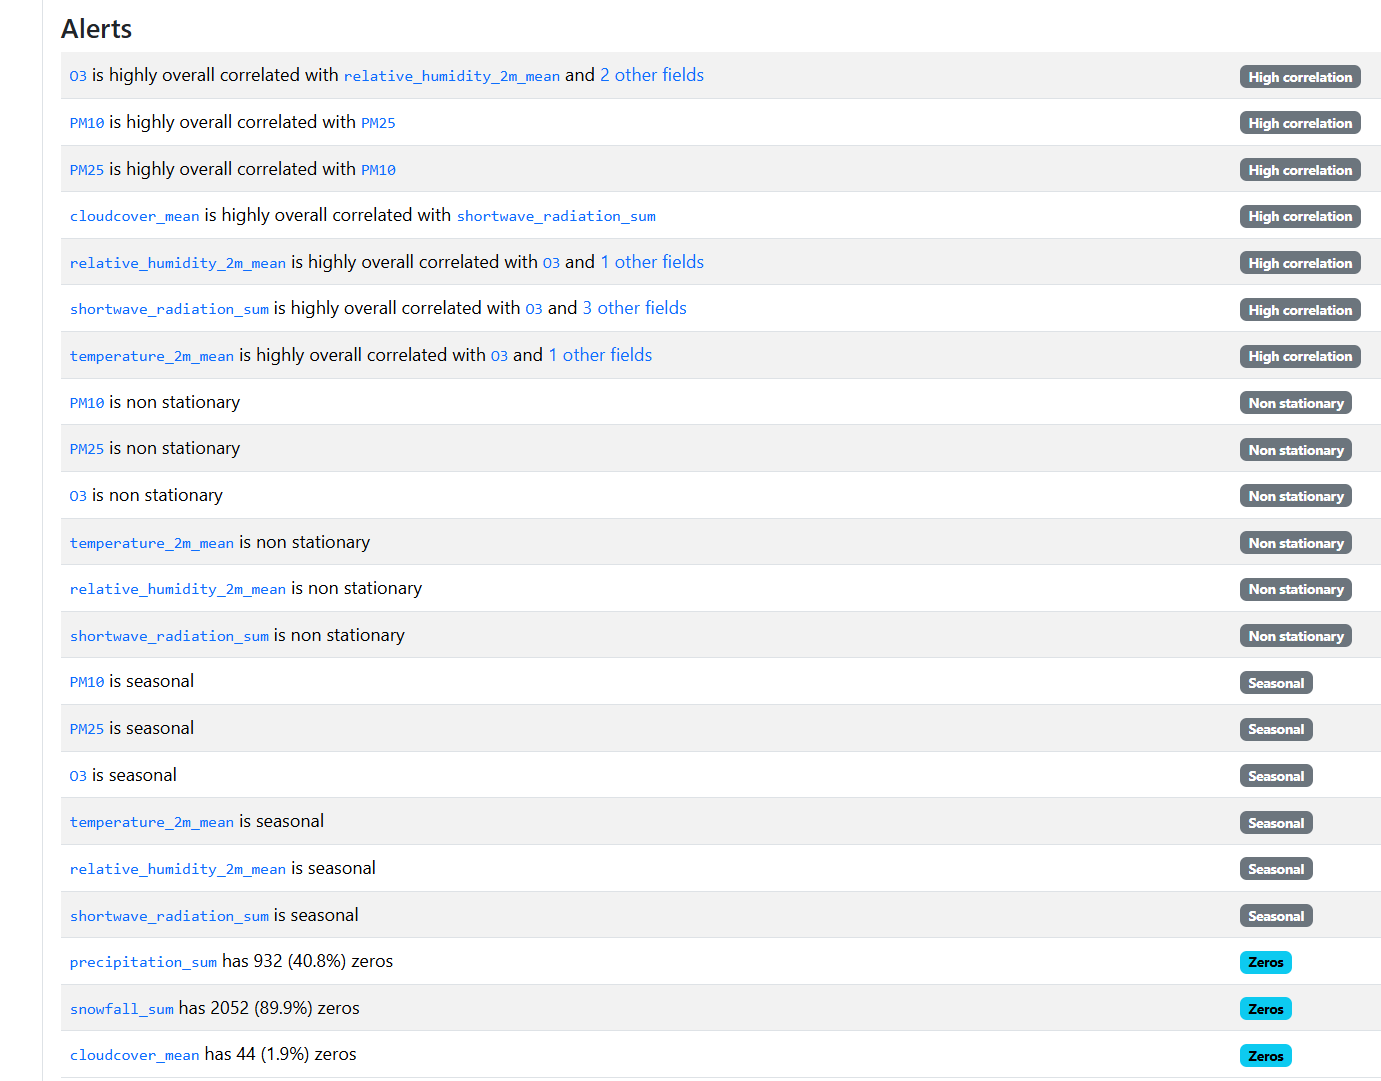

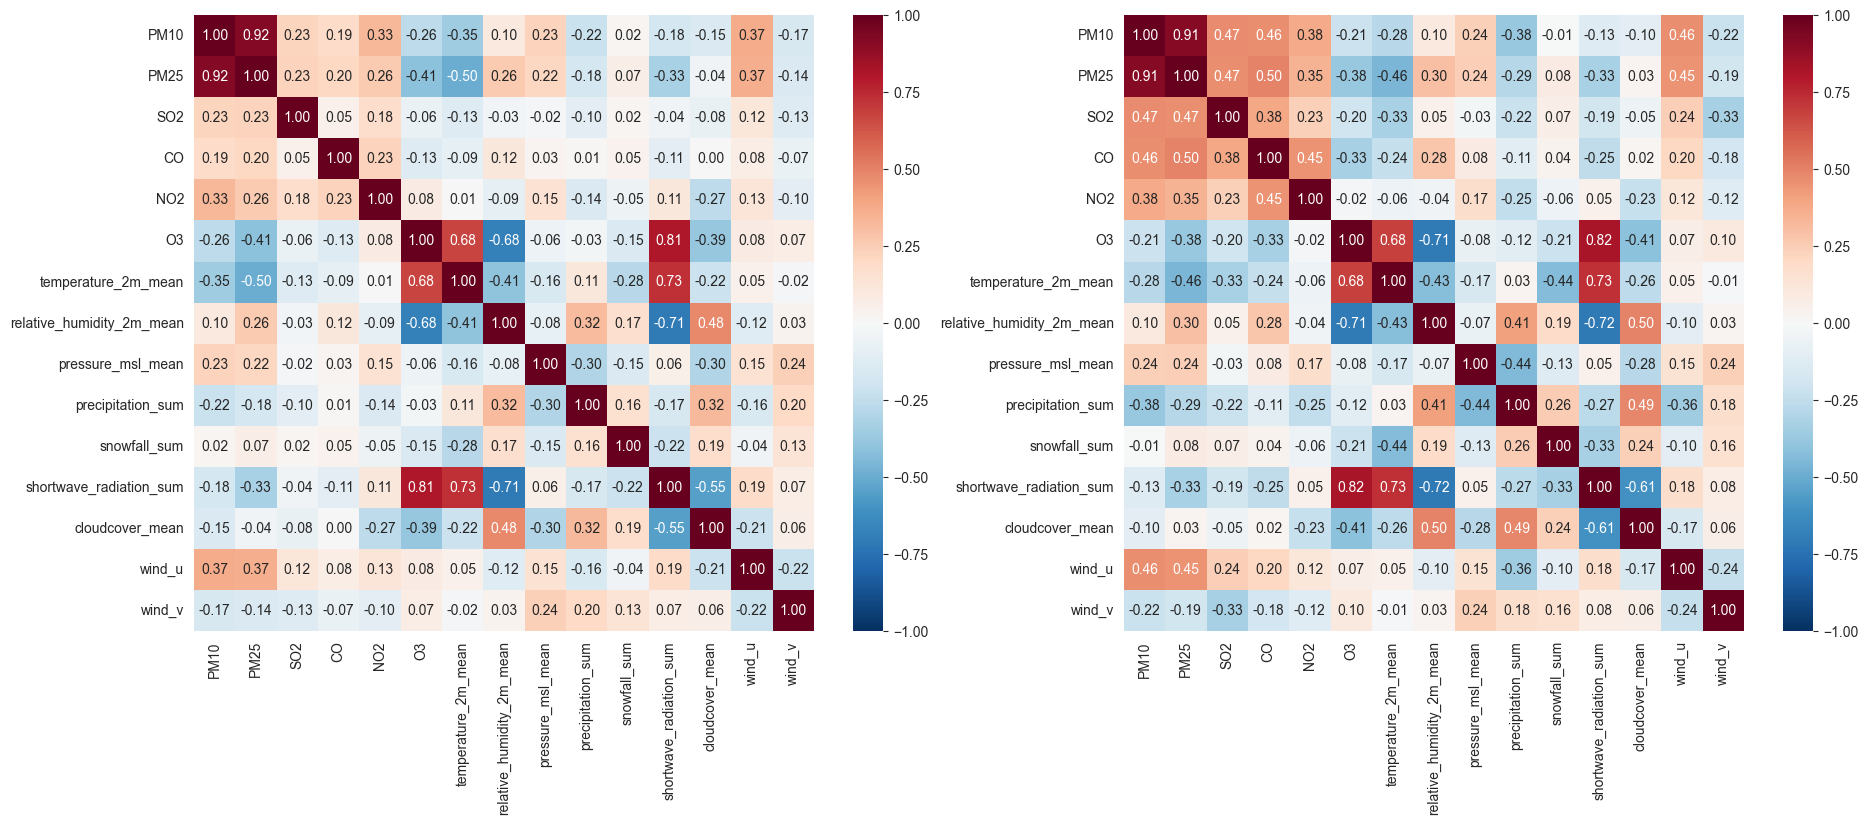

In [630]:
corr_pearson = df.corr(method='pearson')
corr_spearman = df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
sns.heatmap(corr_pearson, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes[0], fmt='.2f')
sns.heatmap(corr_spearman, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes[1], fmt='.2f')
plt.show()

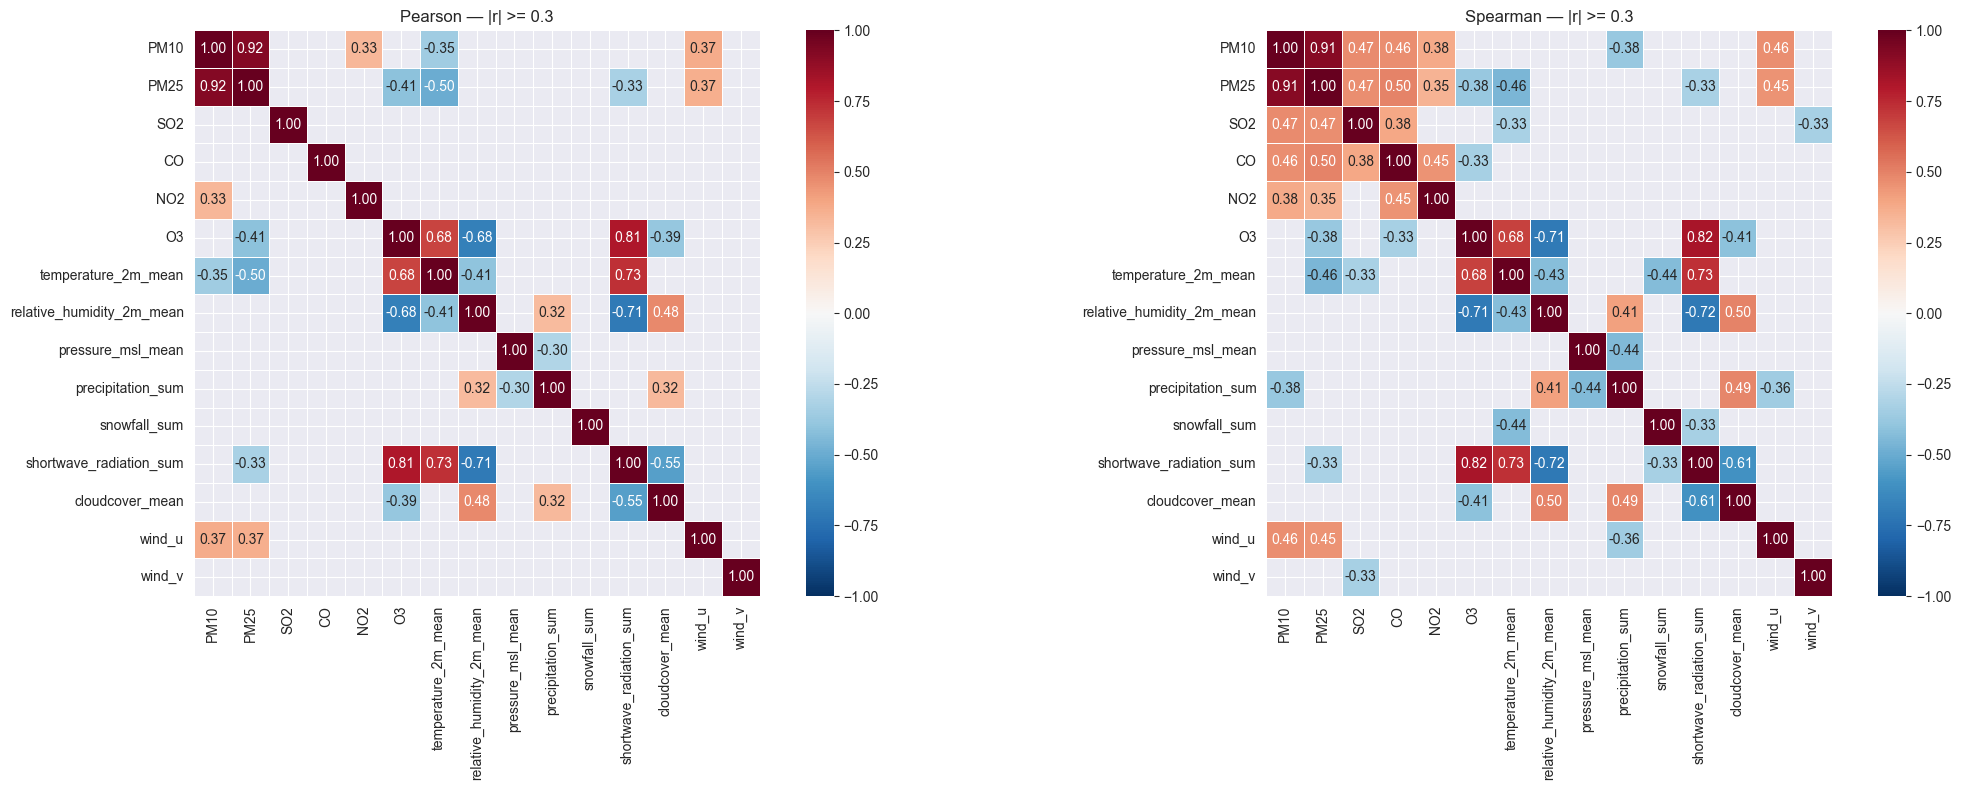

In [631]:
r_df_p = df.corr(method='pearson')
r_df_s = df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(r_df_p, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_p.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[0])
axes[0].set_title('Pearson — |r| >= 0.3')

sns.heatmap(r_df_s, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_s.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[1])
axes[1].set_title('Spearman — |r| >= 0.3') 

plt.tight_layout()
plt.show()

- |r| < 0.1 — efekt zaniedbywalny
- 0.1 <= |r| < 0.3 — efekt mały
- 0.3 <= |r| < 0.5 — efekt średni
- |r| >= 0.5 — efekt duży

Konwencja "small/medium/large effect" Cohena 

In [632]:
POLLUTANTS = ['PM10', 'PM25', 'SO2', 'CO', 'NO2', 'O3']

METEO = ["temperature_2m_mean", 
        'relative_humidity_2m_mean',
        #  'pressure_msl_mean',
         'precipitation_sum',
        #  'snowfall_sum',
         'shortwave_radiation_sum',
         'cloudcover_mean',
         'wind_u',
         'wind_v']

In [633]:
df_old = df.copy()
df = df[POLLUTANTS + METEO]
df_clean = df.copy()

In [634]:
# df['Year'] = df.index.year
df['Month'] = df.index.month_name()
# df['DayOfWeek'] = df.index.day_name()

C:\Users\aleks\AppData\Local\Temp\ipykernel_9256\2236092081.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [635]:
heating_months = ['October', 'November', 'December', 'January', 'February','March']
df['Heating_season'] = df['Month'].isin(heating_months).map({True: 'Heating', False: 'Non-Heating'})

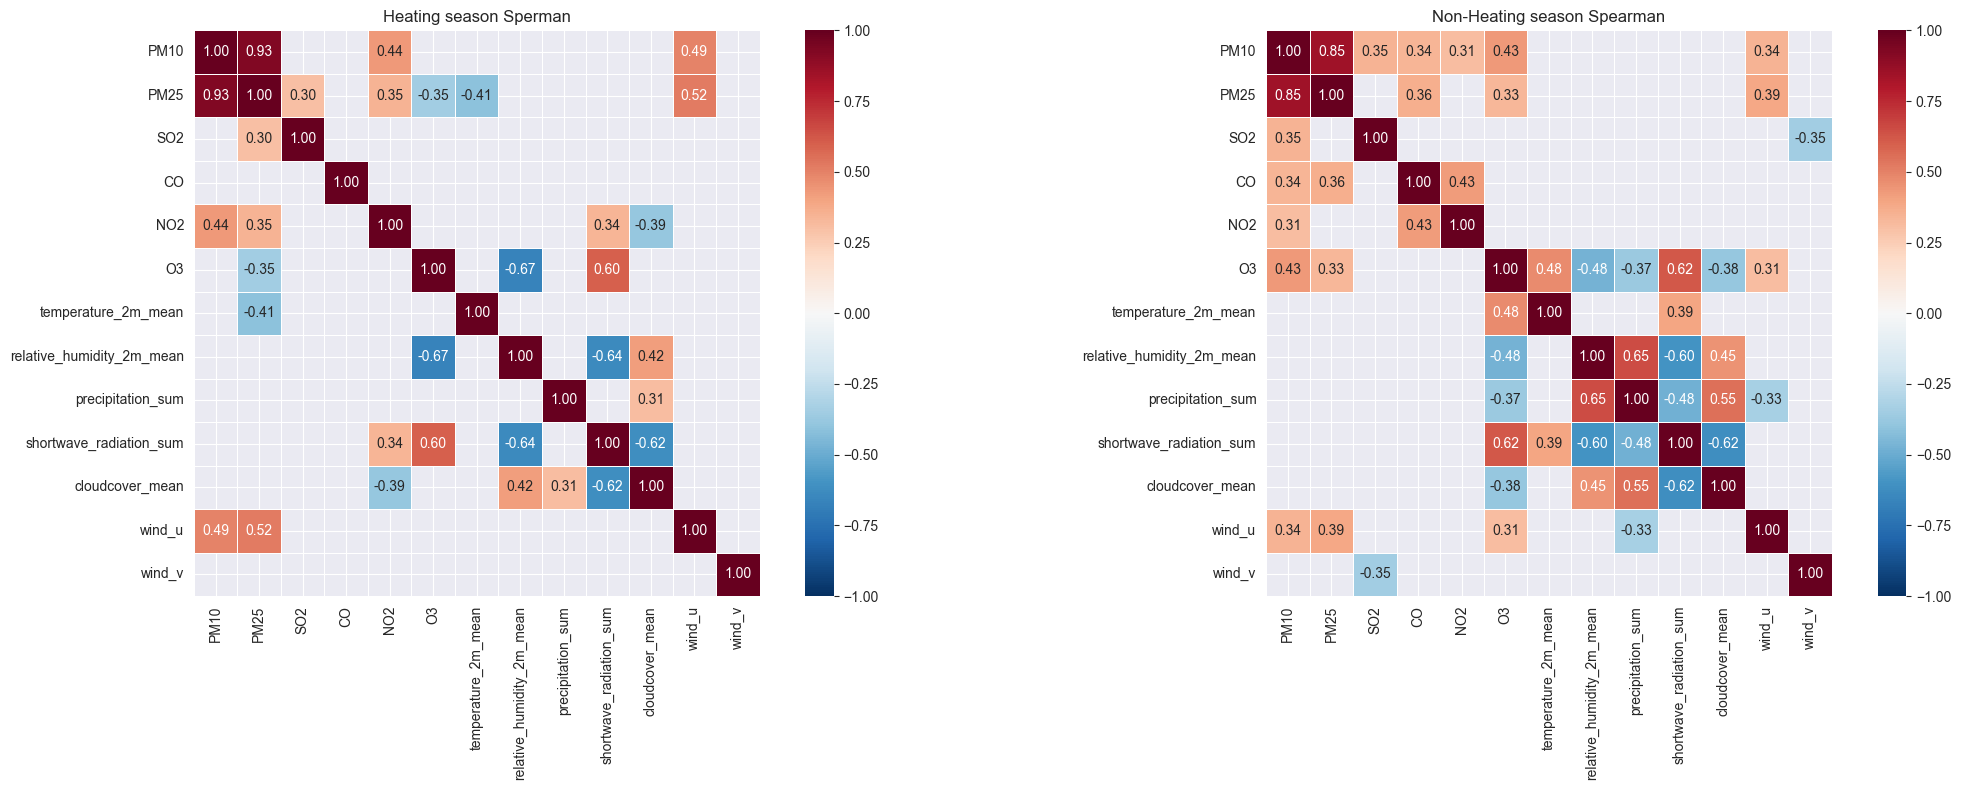

In [636]:
r_df_H = df[df['Heating_season'] == 'Heating'][POLLUTANTS + METEO].corr(method='pearson')
r_df_NH = df[df['Heating_season'] == 'Non-Heating'][POLLUTANTS + METEO].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(r_df_H, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_H.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[0])
axes[0].set_title('Heating season Sperman')

sns.heatmap(r_df_NH, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_NH.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[1])
axes[1].set_title('Non-Heating season Spearman') 

plt.tight_layout()
plt.show()

In [637]:
season_mapping = {
    1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Autumn', 10: 'Autumn',
    11: 'Autumn', 12: 'Winter'
}

df['season'] = df.index.month.map(season_mapping)

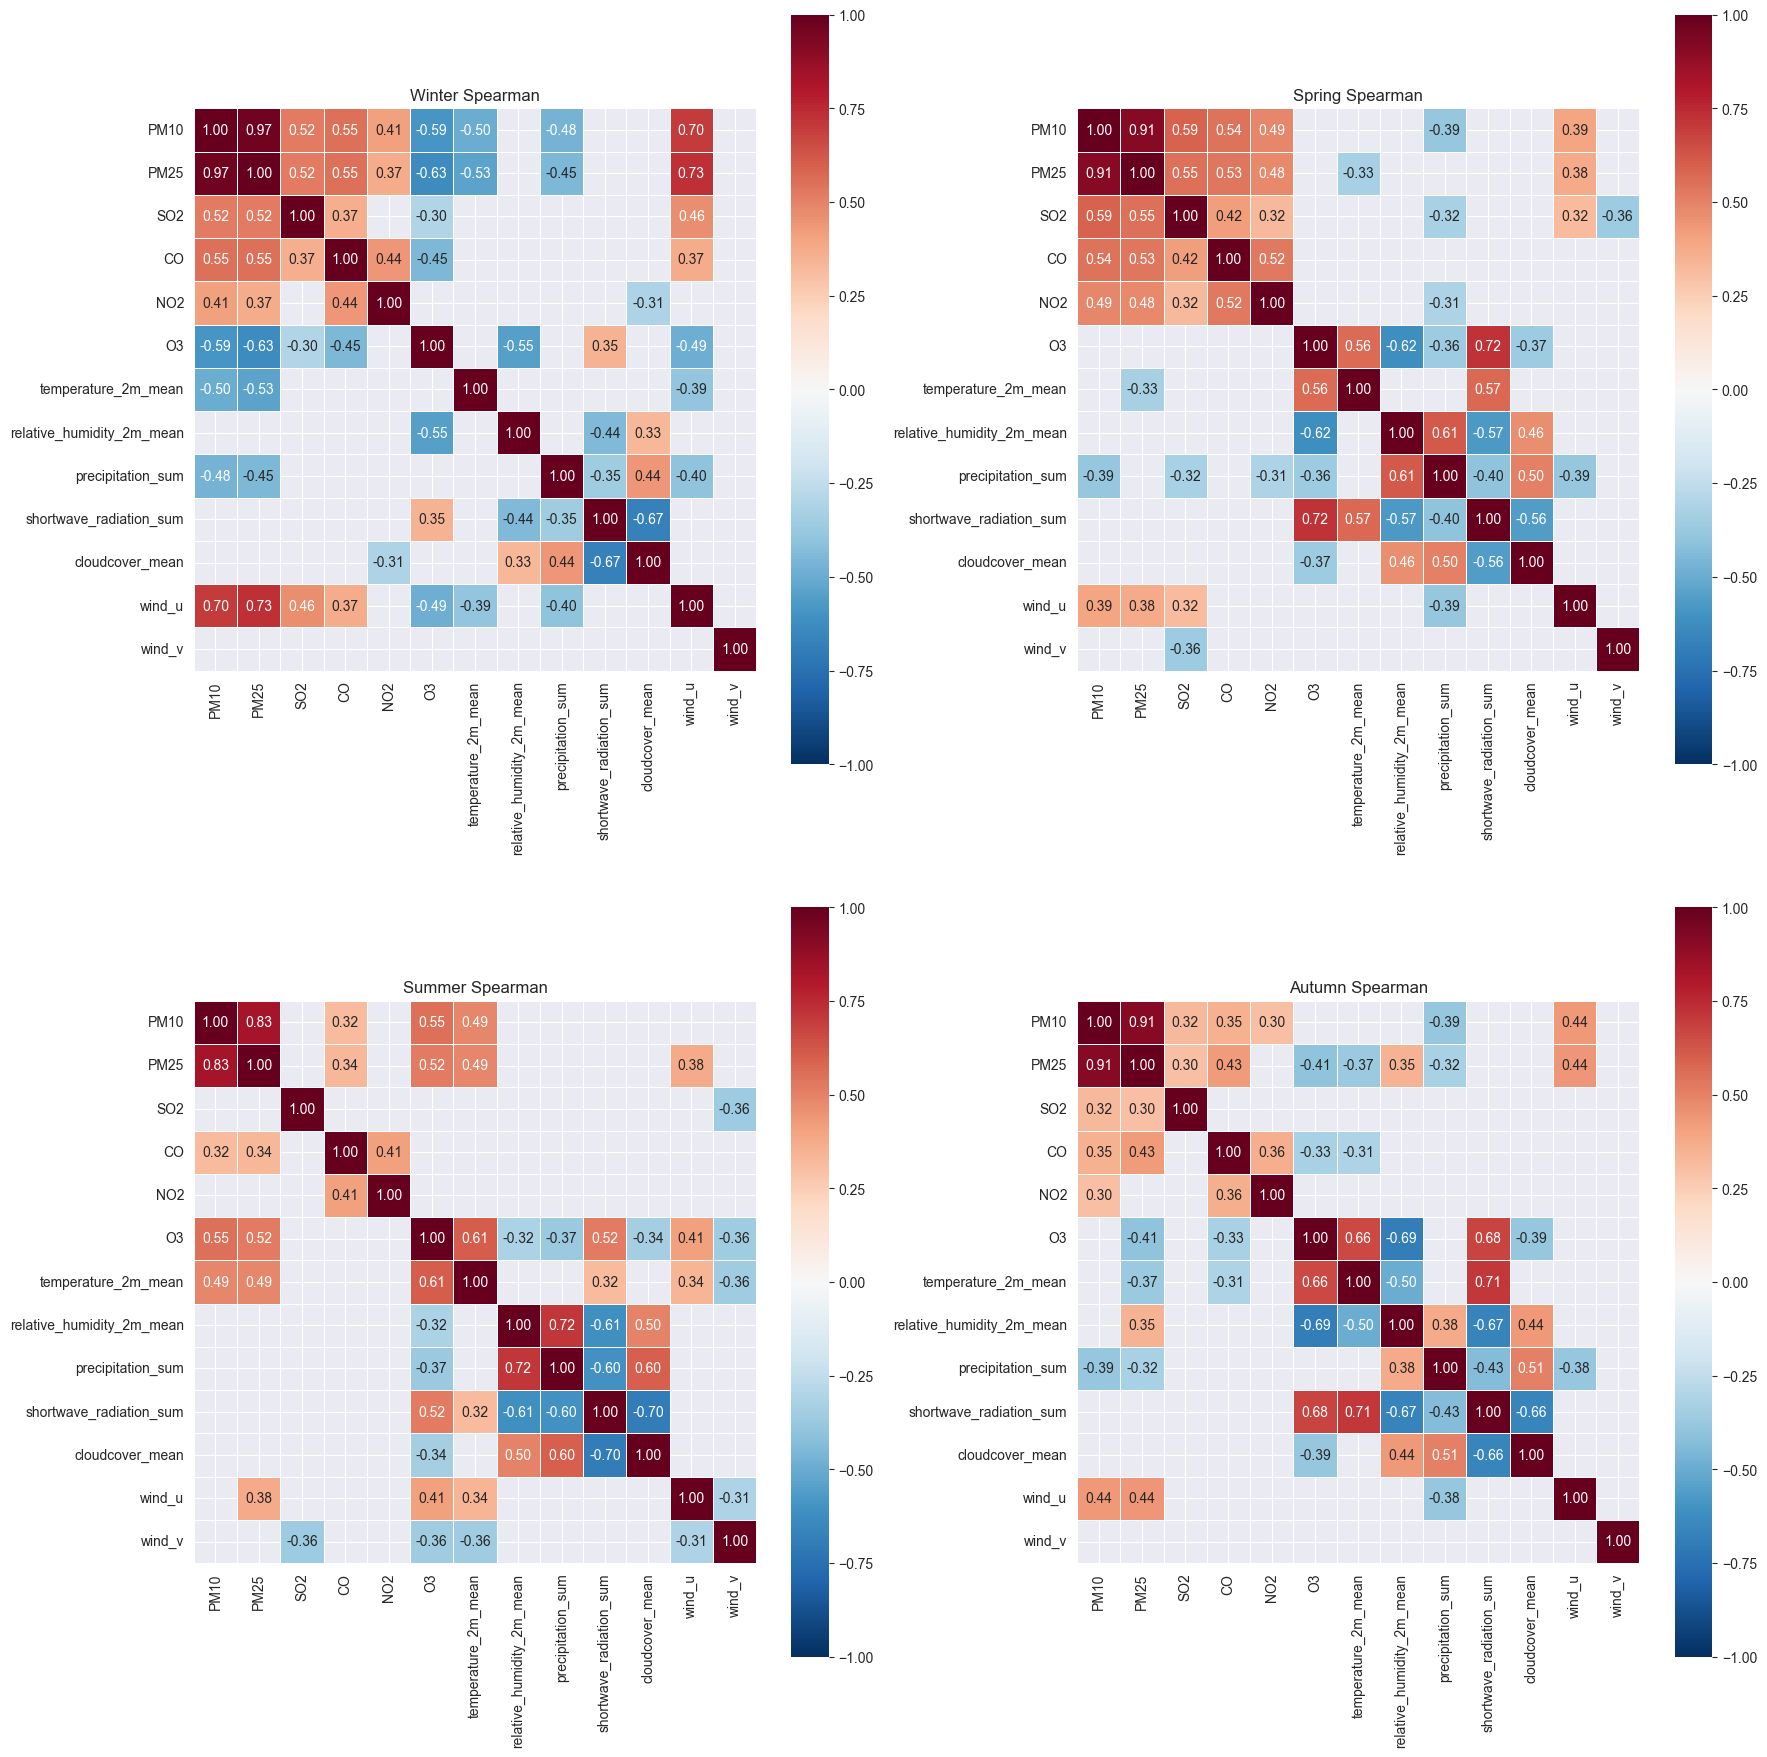

In [638]:
r_df_w = df[df['season'] == 'Winter'][POLLUTANTS + METEO].corr(method='spearman')
r_df_s = df[df['season'] == 'Spring'][POLLUTANTS + METEO].corr(method='spearman')
r_df_su = df[df['season'] == 'Summer'][POLLUTANTS + METEO].corr(method='spearman')
r_df_a = df[df['season'] == 'Autumn'][POLLUTANTS + METEO].corr(method='spearman')

fig, axes = plt.subplots(2, 2, figsize=(18, 18))

sns.heatmap(r_df_w, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_w.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[0, 0])
axes[0, 0].set_title('Winter Spearman')

sns.heatmap(r_df_s, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_s.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[0, 1])
axes[0, 1].set_title('Spring Spearman') 

sns.heatmap(r_df_su, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_su.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[1, 0])
axes[1, 0].set_title('Summer Spearman')

sns.heatmap(r_df_a, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_a.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[1, 1])
axes[1, 1].set_title('Autumn Spearman') 

plt.tight_layout()
plt.show()

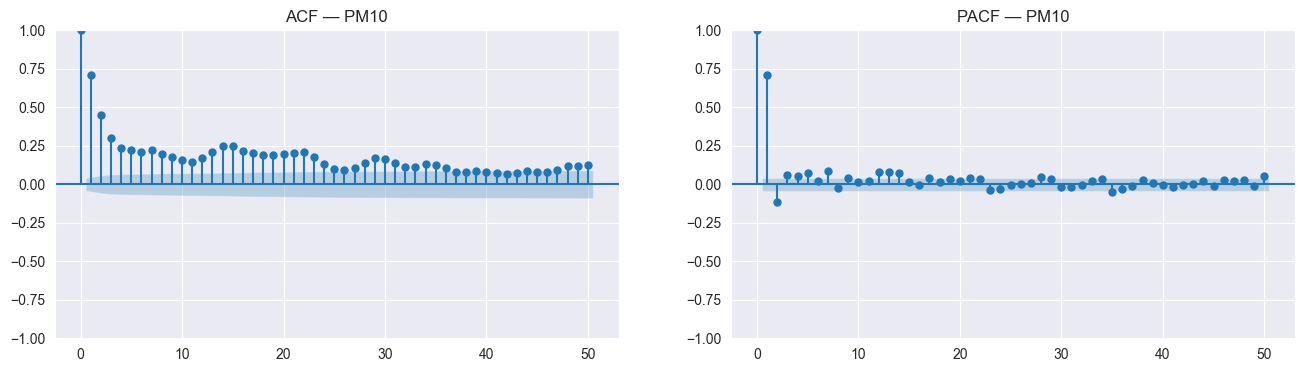

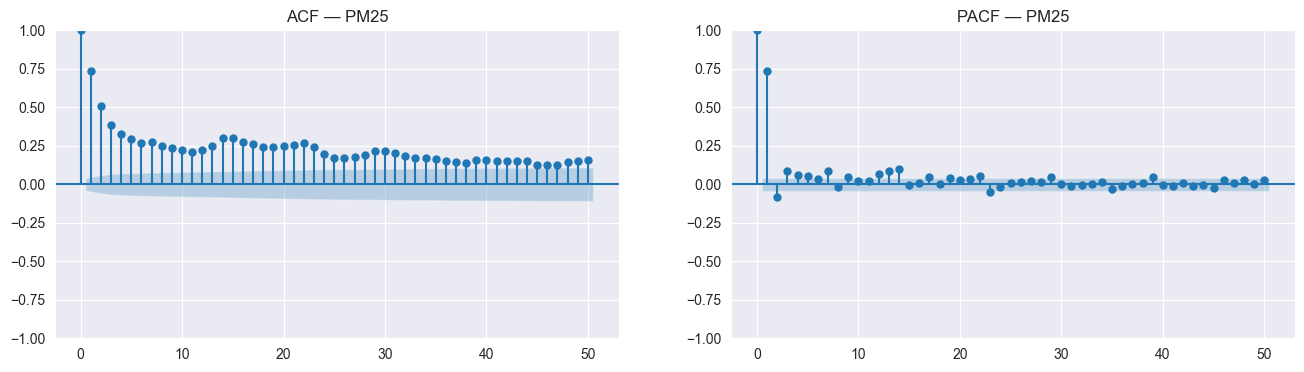

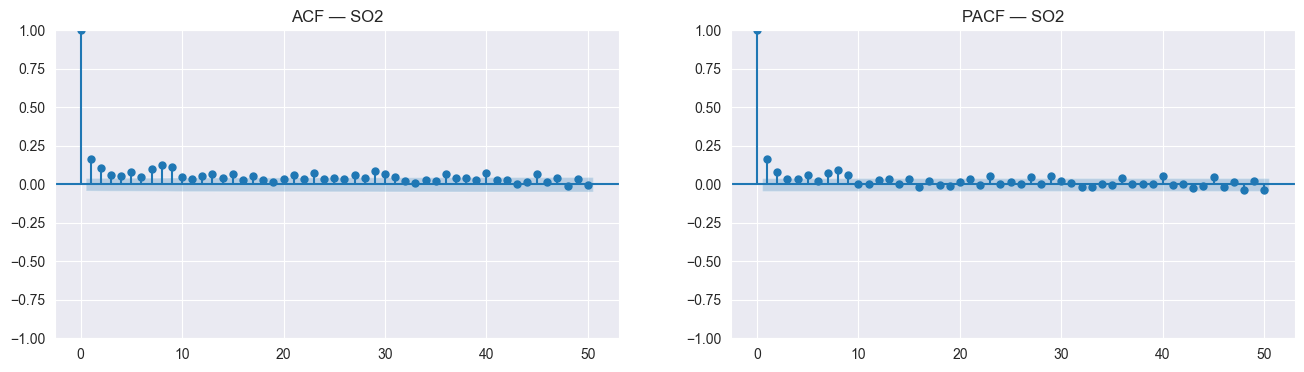

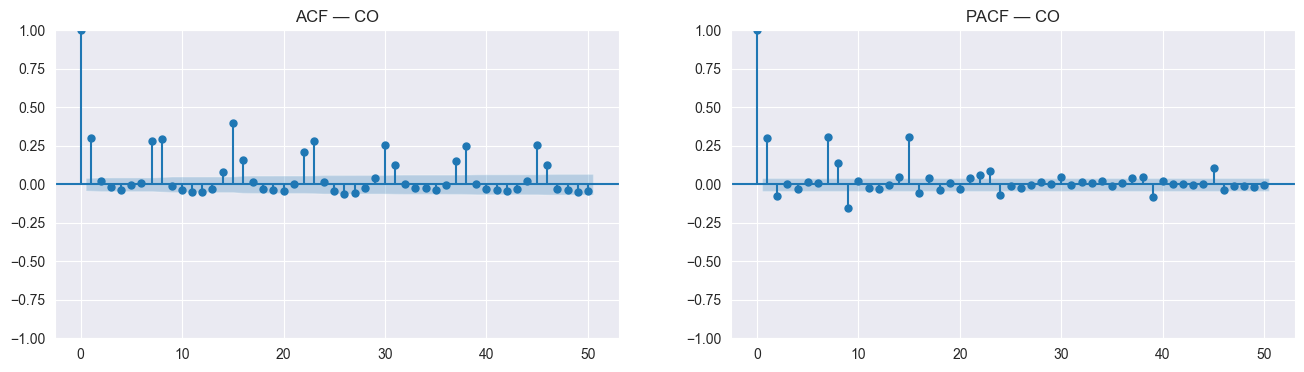

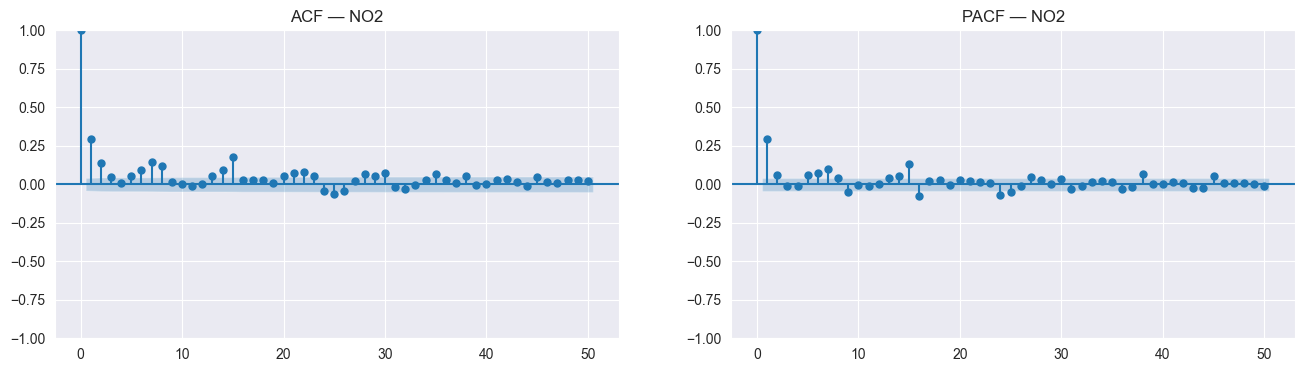

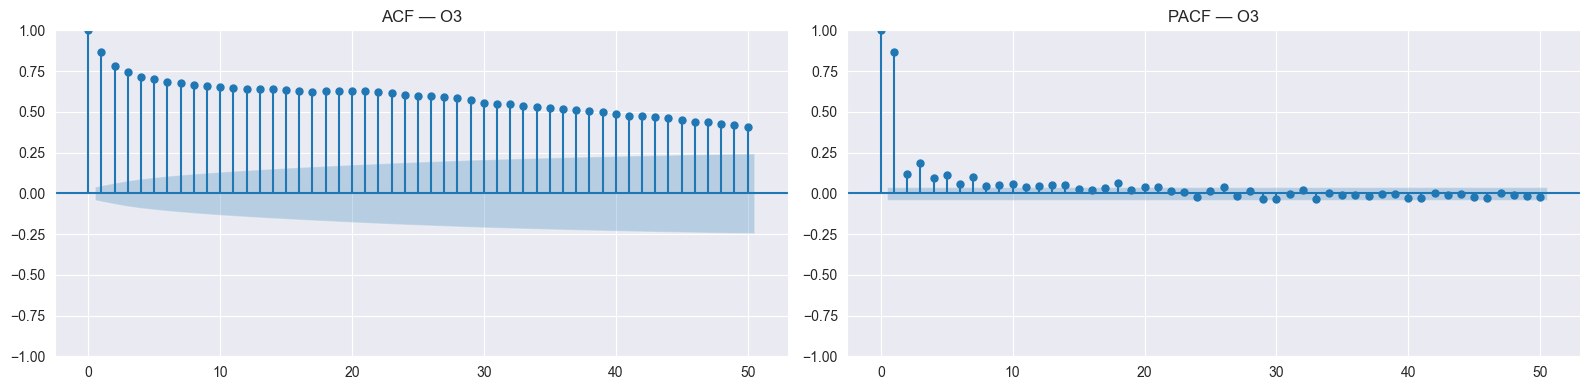

In [639]:
for i, col in enumerate(POLLUTANTS):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))
    s = df[col].dropna()
    plot_acf(s, lags=50, ax=axes[0], title=f'ACF — {col}')
    plot_pacf(s, lags=50, ax=axes[1], title=f'PACF — {col}', method='ywm')
plt.tight_layout()
plt.show()

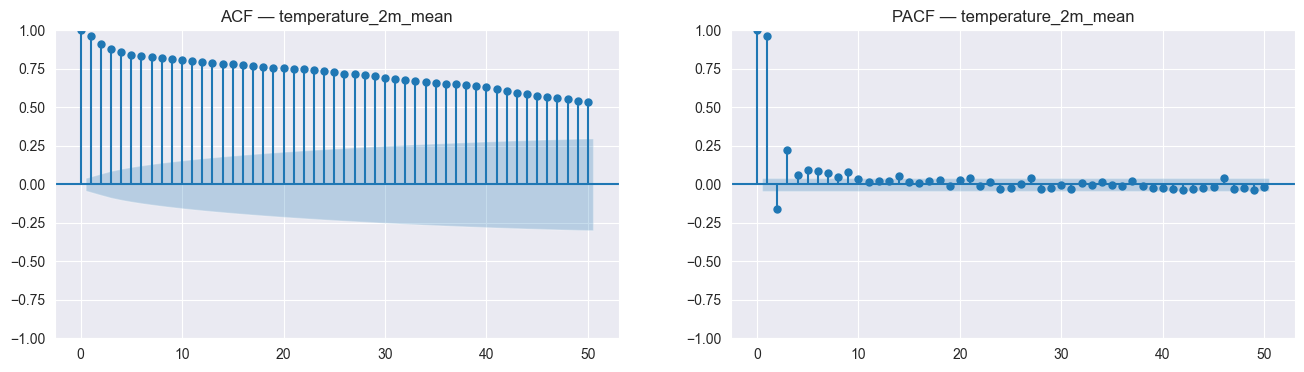

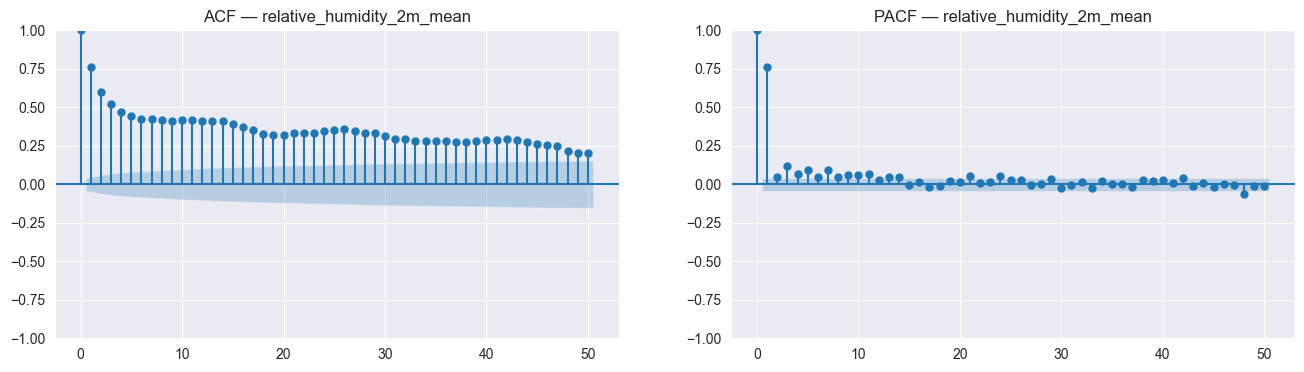

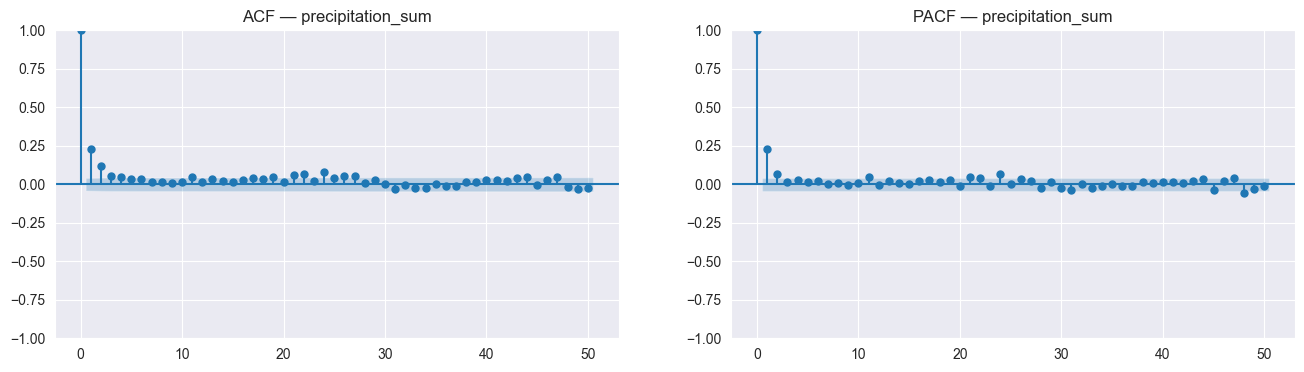

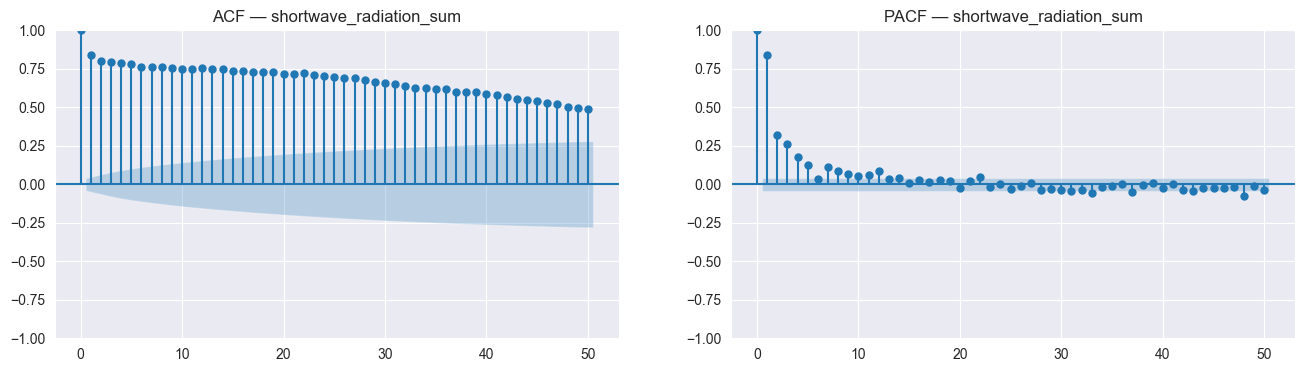

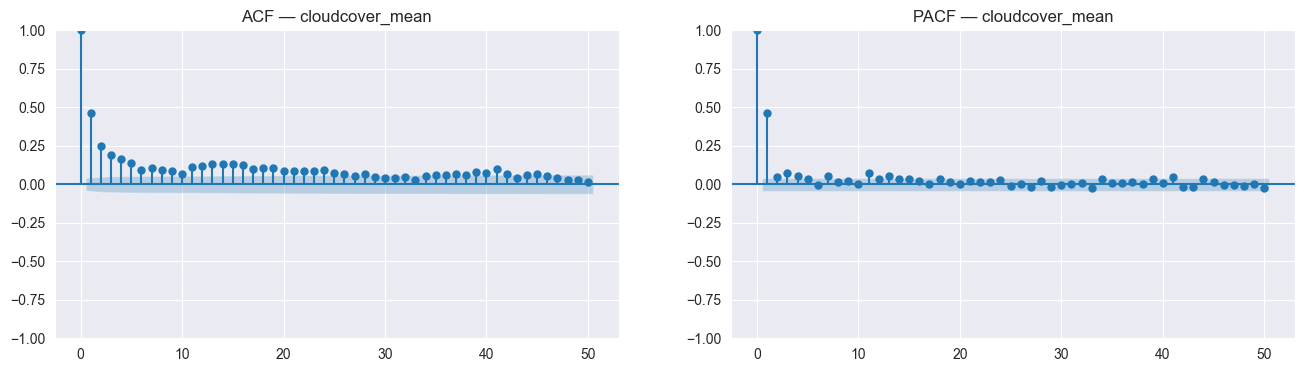

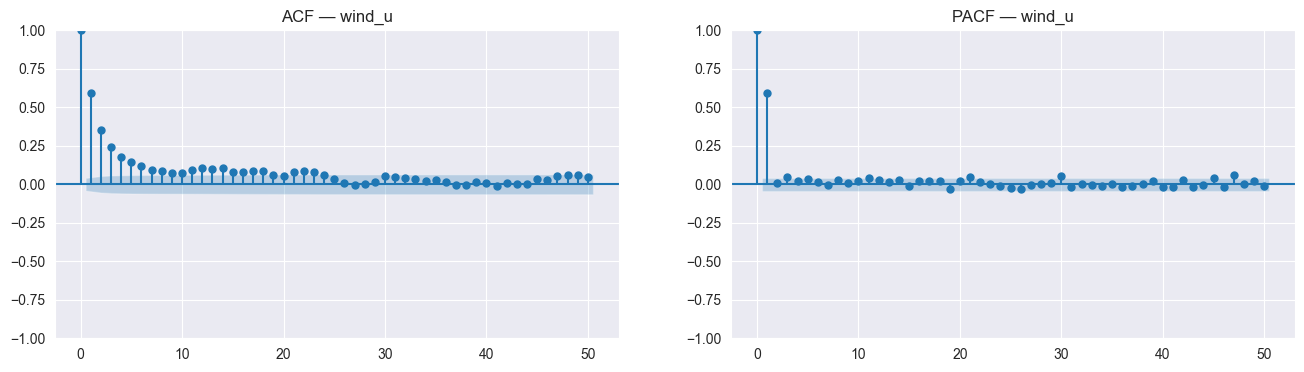

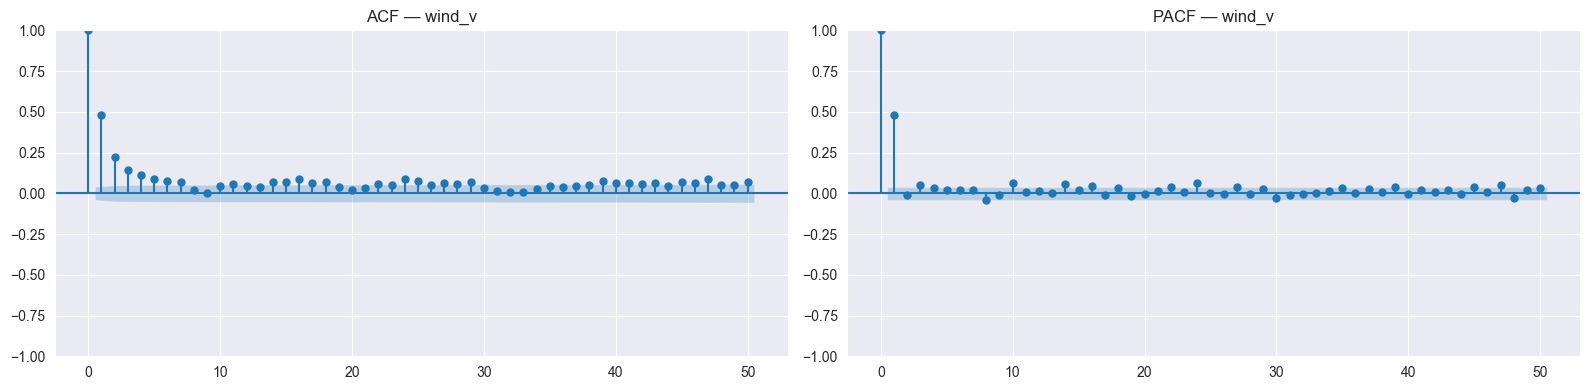

In [640]:
for i, col in enumerate(METEO):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))
    s = df[col].dropna()
    plot_acf(s, lags=50, ax=axes[0], title=f'ACF — {col}')
    plot_pacf(s, lags=50, ax=axes[1], title=f'PACF — {col}', method='ywm')
plt.tight_layout()
plt.show()

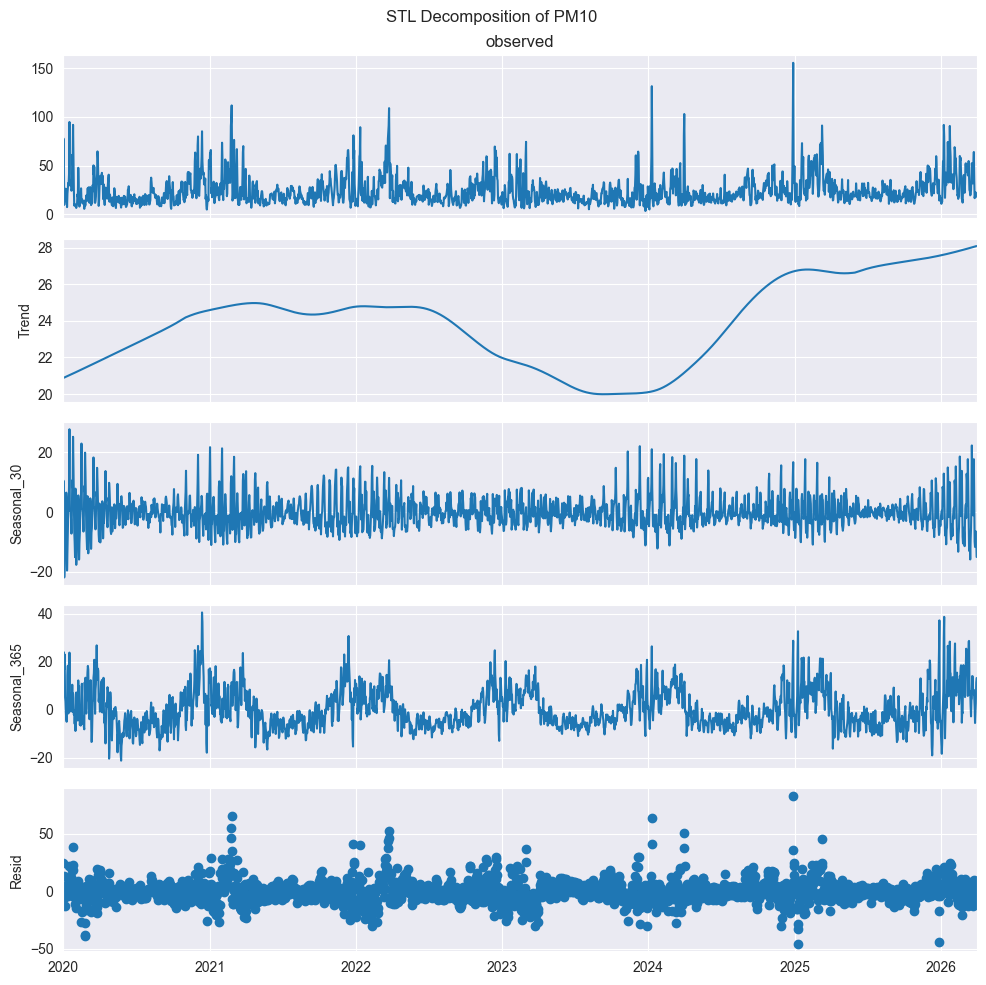

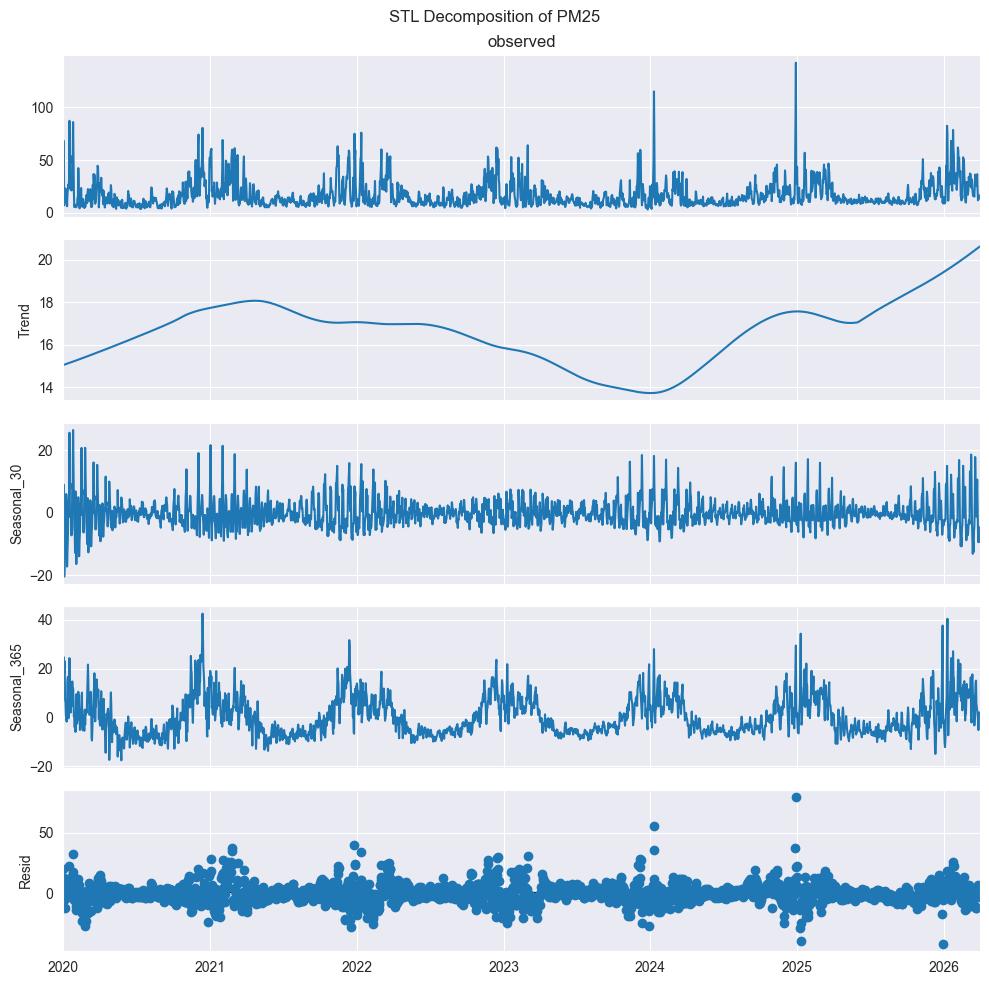

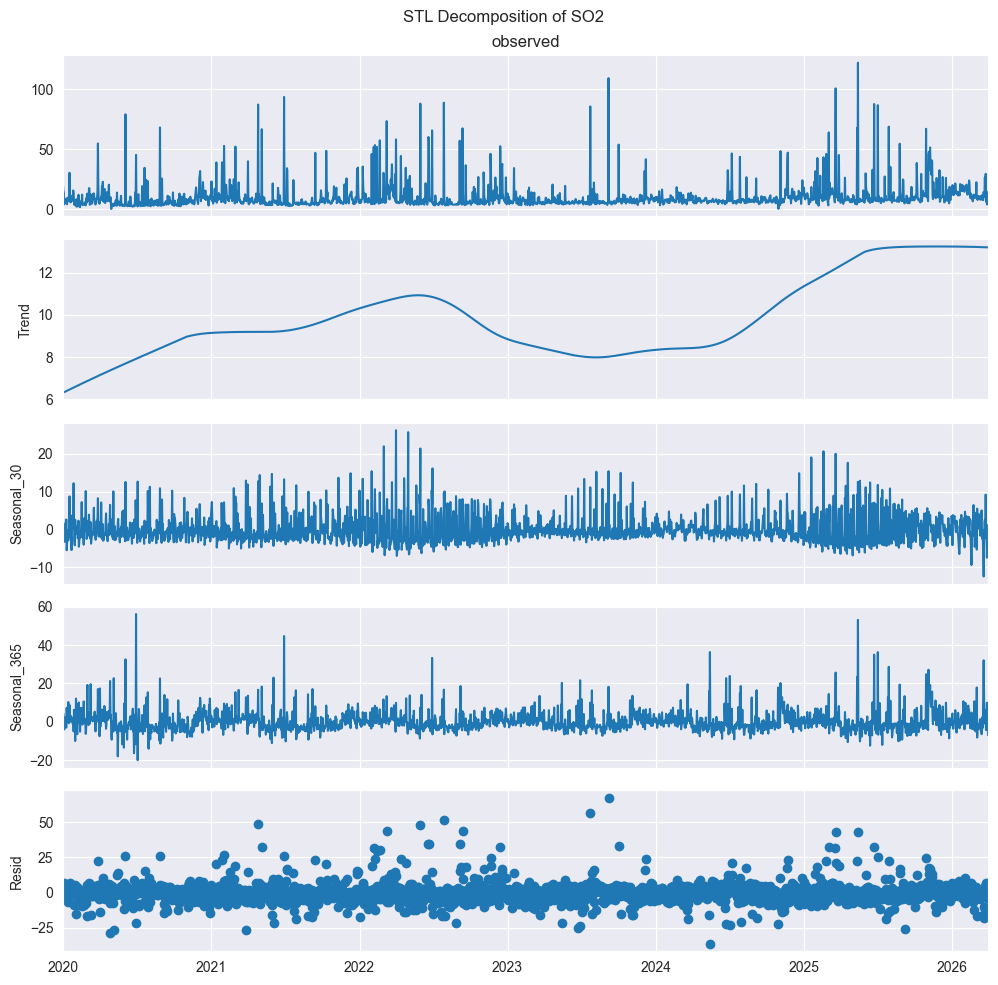

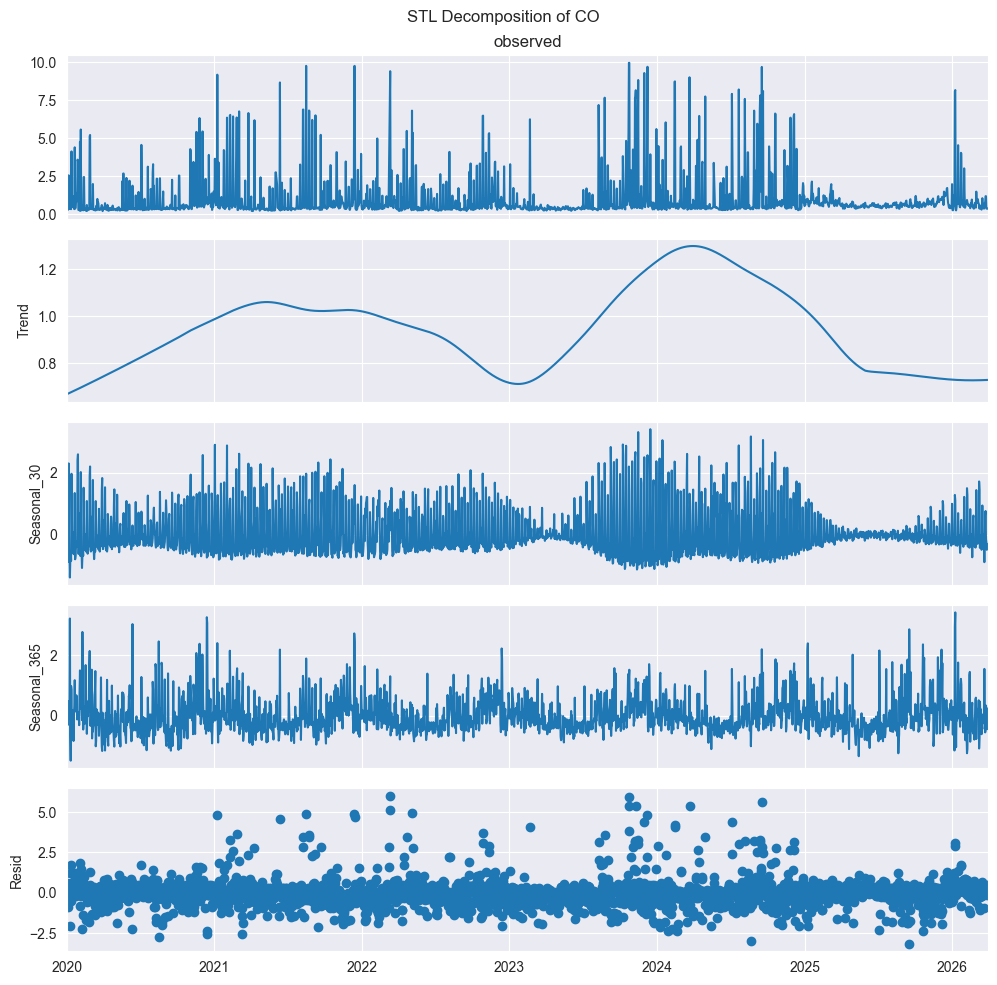

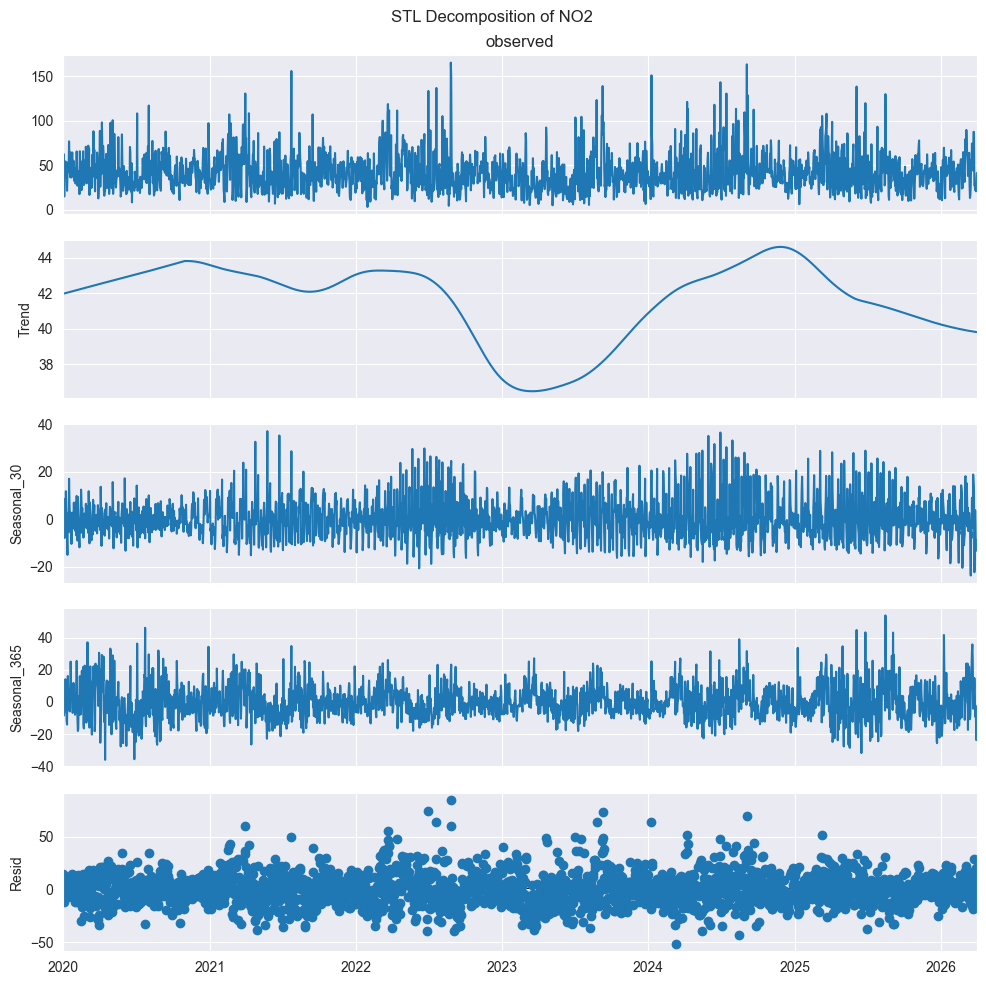

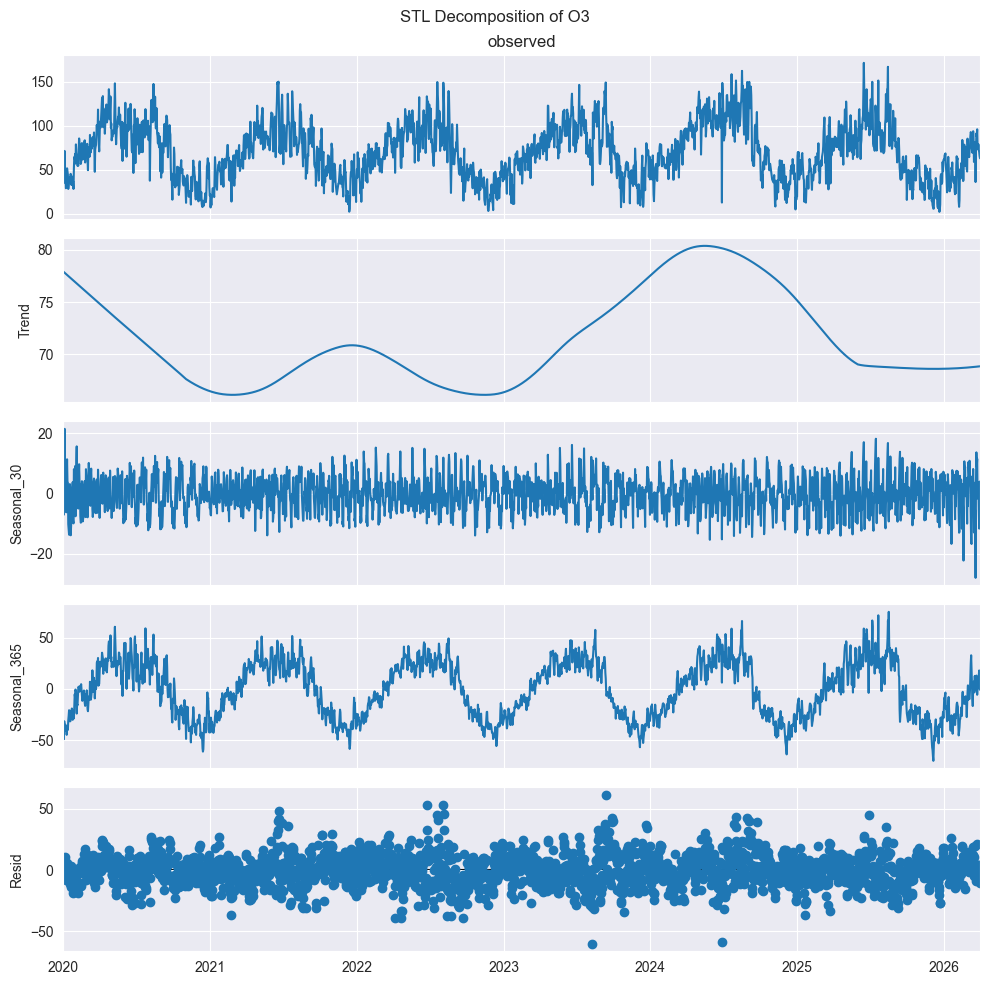

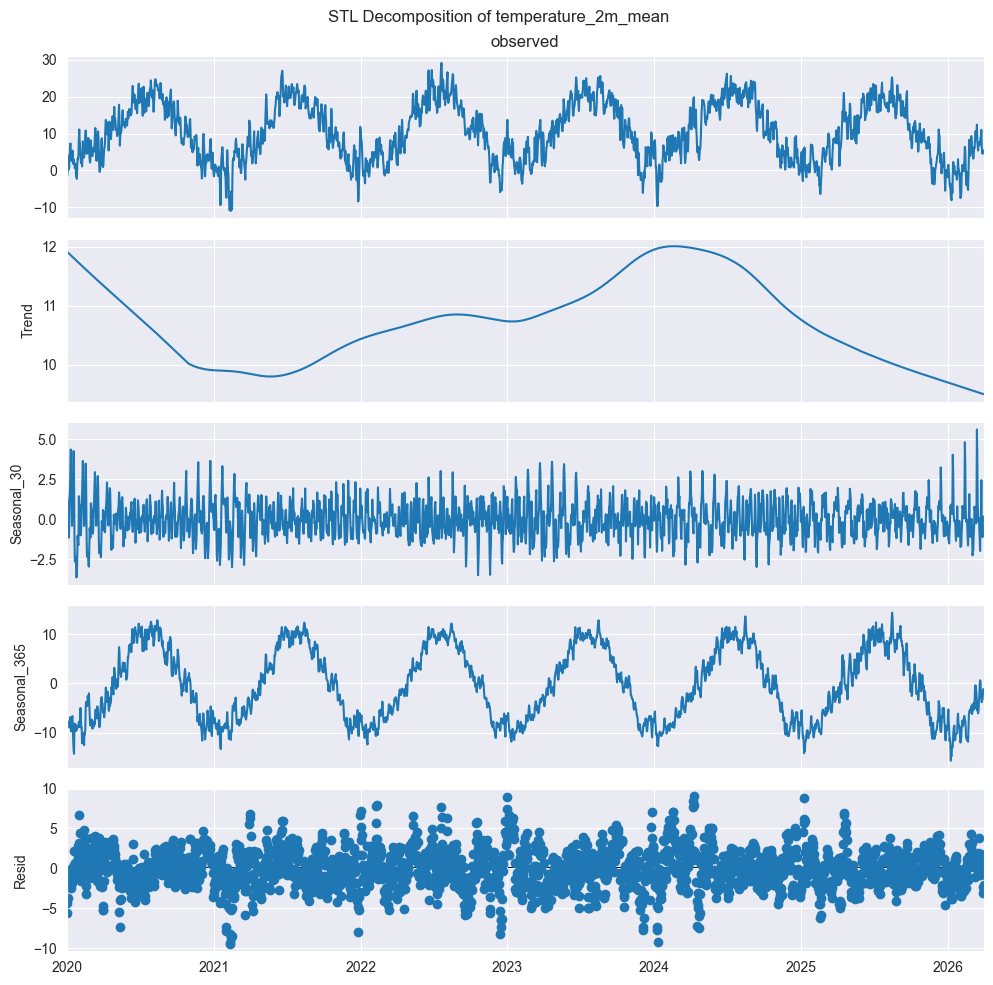

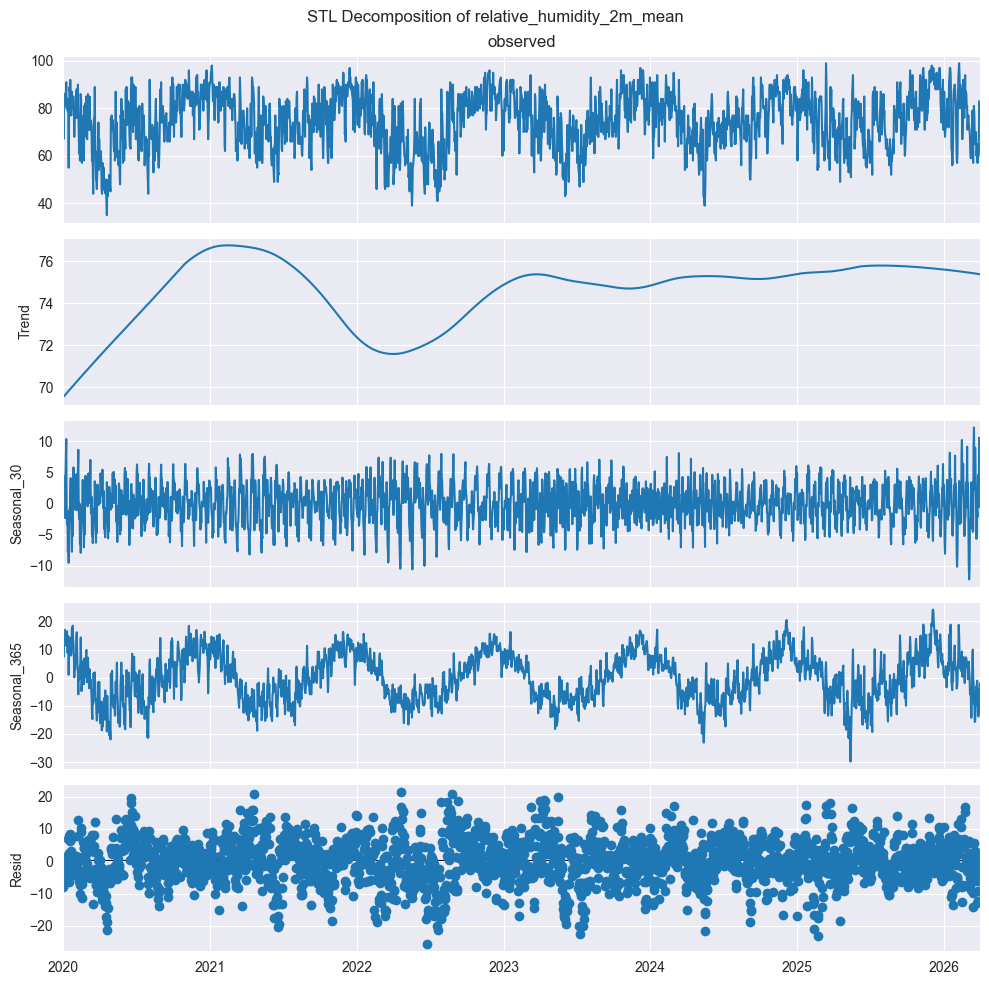

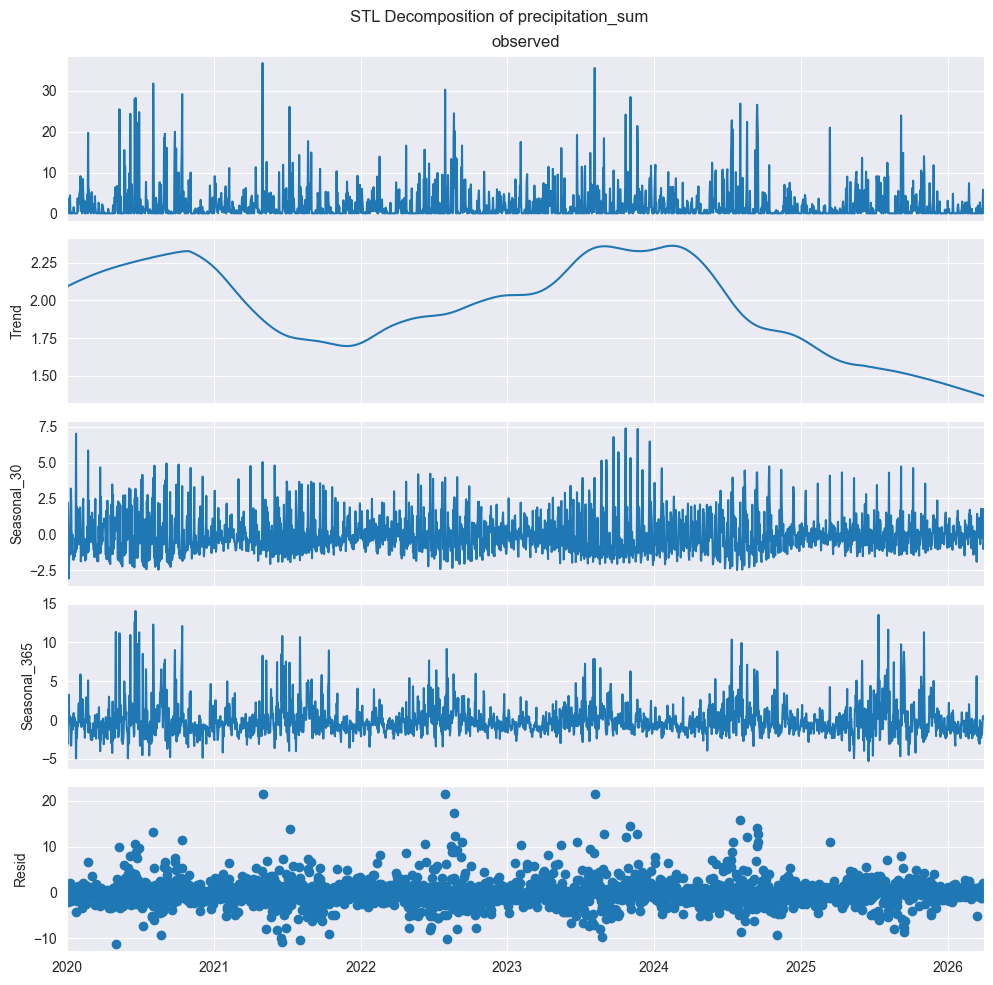

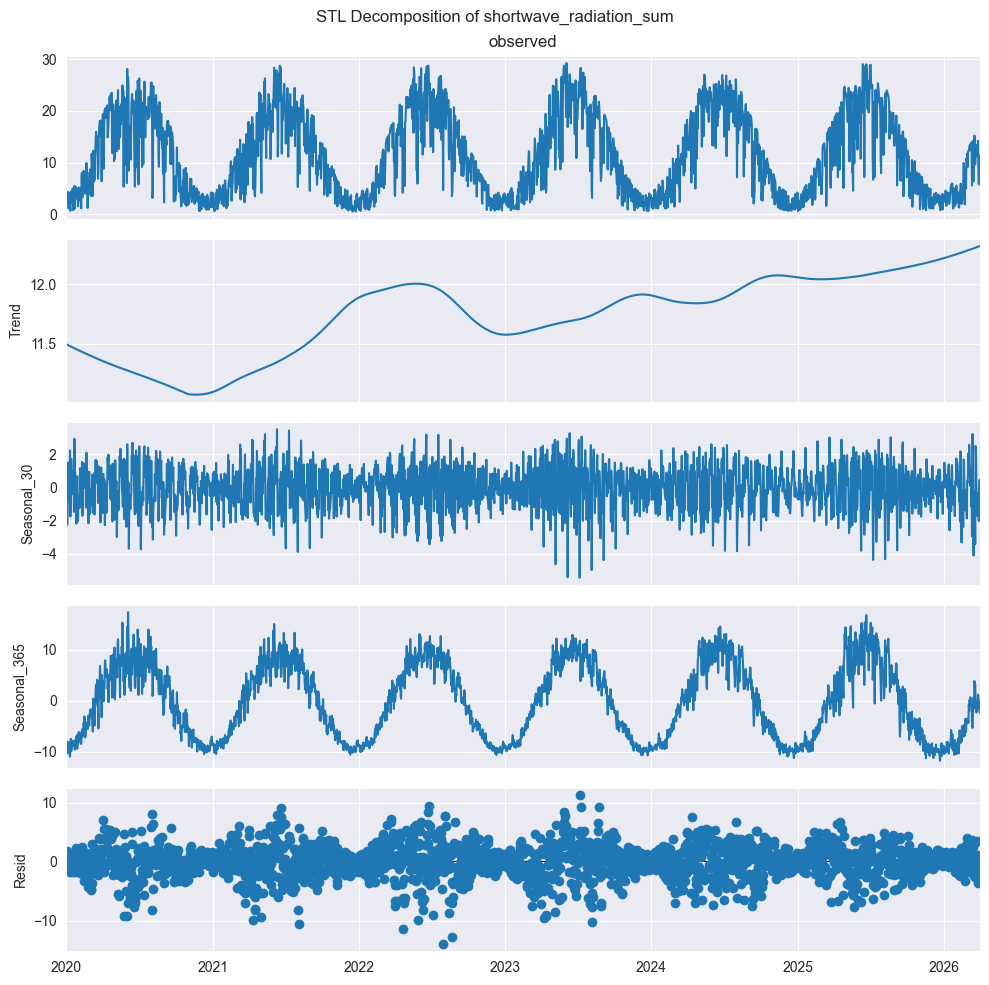

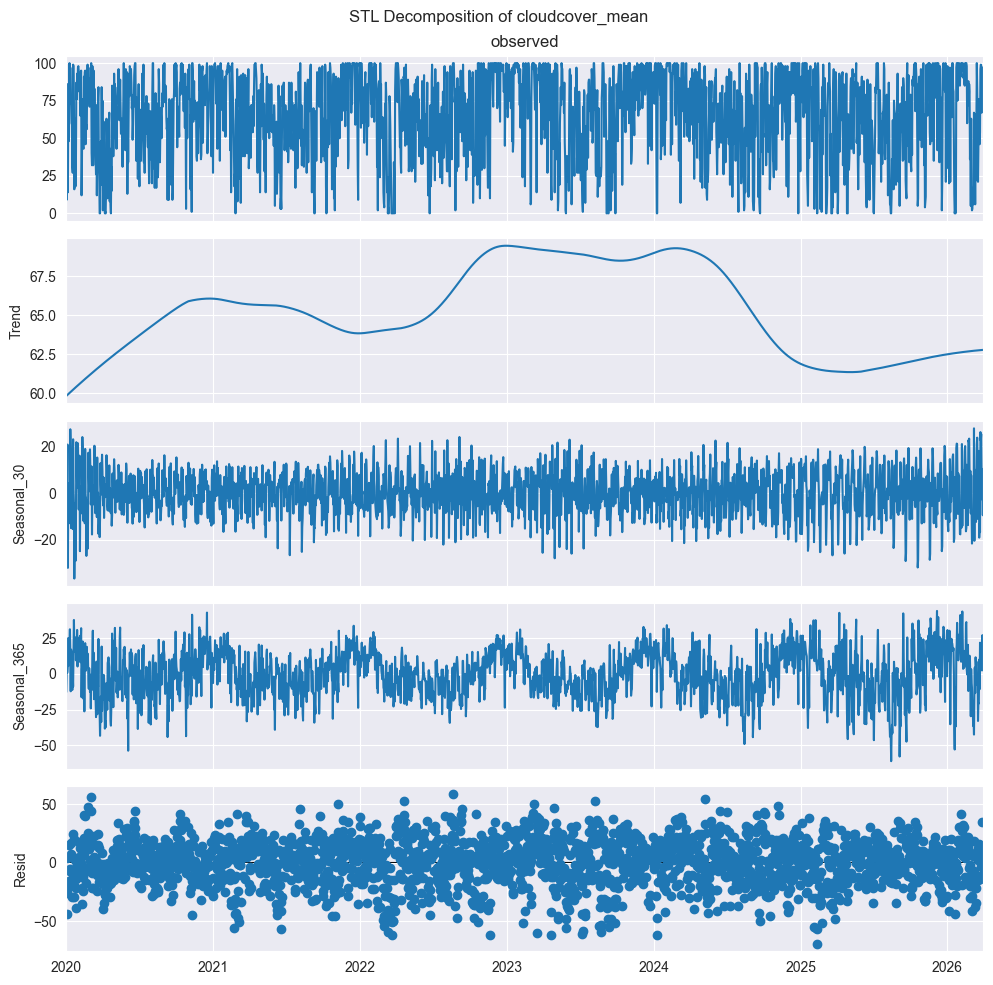

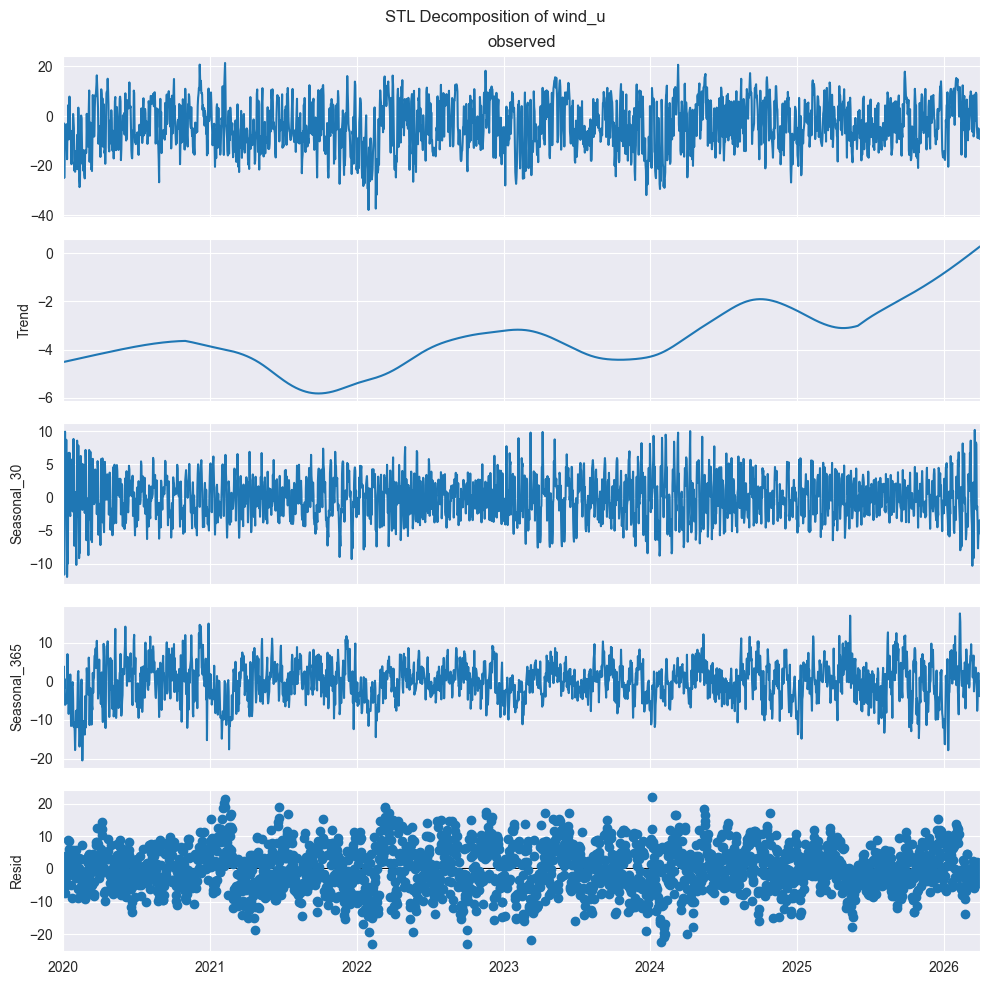

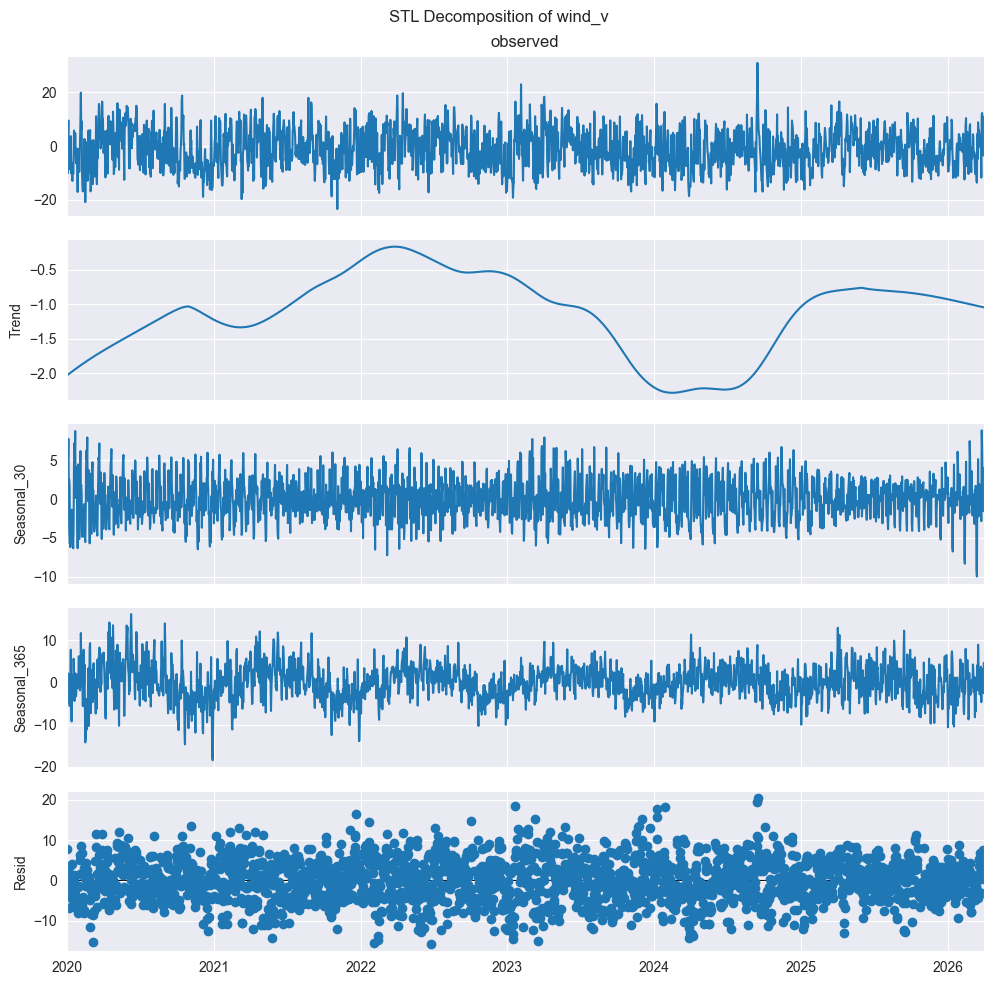

In [641]:
for col in POLLUTANTS + METEO:
    stl =  MSTL(df[col], periods=(30, 365))
    result = stl.fit()
    fig = result.plot()
    fig.set_size_inches(10, 10)
    fig.suptitle(f'STL Decomposition of {col}')
    plt.tight_layout()
    plt.show()

In [642]:
rows = [check_stationarity(df[col], name=col) for col in POLLUTANTS + METEO]
stationarity_table = pd.DataFrame(rows)

stationarity_table

,variable,ADF_stat,ADF_p,ADF_result,KPSS_stat,KPSS_p,KPSS_result,conclusion
0,PM10,-5.955,0.000,Stationary,0.391,0.081,Stationary,Stationary
1,PM25,-5.351,0.000,Stationary,0.179,0.100,Stationary,Stationary
2,SO2,-11.277,0.000,Stationary,1.496,0.010,Non-stationary,Seasonal/trend-stationary
3,CO,-6.382,0.000,Stationary,0.315,0.100,Stationary,Stationary
4,NO2,-7.576,0.000,Stationary,0.239,0.100,Stationary,Stationary
5,O3,-3.164,0.022,Stationary,0.096,0.100,Stationary,Stationary
6,temperature_2m_mean,-3.262,0.017,Stationary,0.093,0.100,Stationary,Stationary
7,relative_humidity_2m_mean,-5.557,0.000,Stationary,0.199,0.100,Stationary,Stationary
8,precipitation_sum,-27.704,0.000,Stationary,0.268,0.100,Stationary,Stationary
9,shortwave_radiation_sum,-2.906,0.045,Stationary,0.068,0.100,Stationary,Stationary


- Case 1: Both tests conclude that the series is not stationary - The series is not stationary
- Case 2: Both tests conclude that the series is stationary - The series is stationary
- Case 3: KPSS indicates stationarity and ADF indicates non-stationarity - The series is trend stationary. Trend needs to be removed to make series strict stationary. The detrended series is checked for stationarity.
- Case 4: KPSS indicates non-stationarity and ADF indicates stationarity - The series is difference stationary. Differencing is to be used to make series stationary. The differenced series is checked for stationarity.
-biblioteka stats


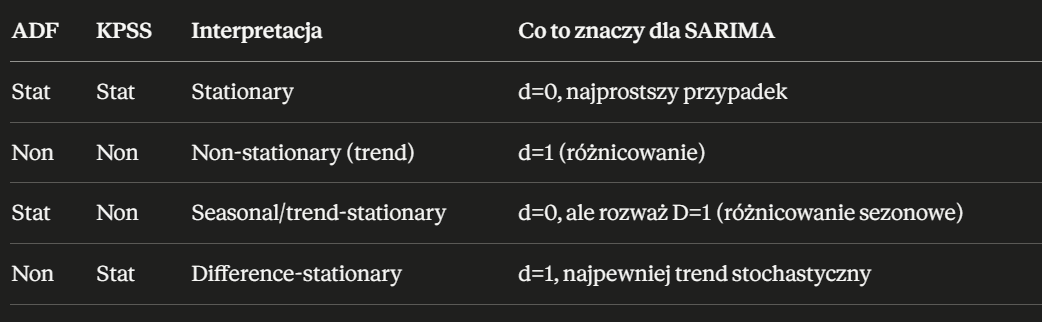

In [643]:
df_dumm = df_clean.copy()

df_clean = df_clean.asfreq('D')
df_dumm = df_dumm.asfreq('D')

In [644]:
dummies = pd.get_dummies(df_dumm.index.month, prefix='month').astype(int)
dummies.index = df_dumm.index

dummies_train = dummies.loc[:'2025-03-30']
dummies_test = dummies.loc['2025-03-31':]

df_train = df_clean.loc[:'2025-03-30']
df_test = df_clean.loc['2025-03-31':]

In [645]:
def SARIMAX_grid_search(df_train, target, exog, p_values, d_values, q_values, verbose=False):
    y_train = df_train[target]
    
    best_aic = np.inf
    best_order = None
    
    for p, d, q in itertools.product(p_values, d_values, q_values):
        try:
            model = SARIMAX(
                y_train,
                exog=exog,
                order=(p, d, q),
                seasonal_order=(0, 0, 0, 0),
                trend='n',
                missing='drop',
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fit = model.fit(disp=False)
            if verbose:
                print(f"  ({p},{d},{q}): AIC={fit.aic:.2f}")
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = (p, d, q)
        except Exception:
            continue
    
    print(f"{target}: Best SARIMA order={best_order}, AIC={best_aic:.2f}")
    
    sarima = SARIMAX(
        y_train,
        exog=exog,
        order=best_order,
        seasonal_order=(0, 0, 0, 0),
        trend='n',
        missing='drop',
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fit = sarima.fit(disp=False)
    print(sarima_fit.summary())
    print('\n')
    
    return sarima_fit, best_order, best_aic

In [646]:
assert df_train.index.equals(dummies_train.index)

fitted_models = {}
orders = {}
aics = {}

for col in POLLUTANTS:
    print(f"\n{'='*60}")
    print(f"Polutant: {col}")
    
    fit, order, aic = SARIMAX_grid_search(
        df_train, col, dummies_train,
        p_values=[0, 1, 2, 3],
        d_values=[0],
        q_values=[0, 1, 2, 3]
    )
    
    fitted_models[col] = fit
    orders[col] = order
    aics[col] = aic


for col in POLLUTANTS:
    print(f"{col}: order={orders[col]}, AIC={aics[col]:.2f}")


Polutant: PM10


c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



PM10: Best SARIMA order=(1, 0, 3), AIC=14283.24
                               SARIMAX Results                                
Dep. Variable:                   PM10   No. Observations:                 1916
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -7124.618
Date:                Tue, 12 May 2026   AIC                          14283.237
Time:                        09:08:36   BIC                          14377.687
Sample:                    01-01-2020   HQIC                         14317.996
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_1       26.4107      1.402     18.838      0.000      23.663      29.159
month_2       27.1090      1.478     18.338      0.000      24.212      30.006
mont

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



PM25: Best SARIMA order=(1, 0, 3), AIC=13506.22
                               SARIMAX Results                                
Dep. Variable:                   PM25   No. Observations:                 1916
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -6736.111
Date:                Tue, 12 May 2026   AIC                          13506.222
Time:                        09:09:55   BIC                          13600.672
Sample:                    01-01-2020   HQIC                         13540.981
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_1       20.5847      1.120     18.383      0.000      18.390      22.779
month_2       20.3457      1.229     16.550      0.000      17.936      22.755
mont

...

CO: Best SARIMA order=(2, 0, 3), AIC=6535.39
                               SARIMAX Results                                
Dep. Variable:                     CO   No. Observations:                 1916
Model:               SARIMAX(2, 0, 3)   Log Likelihood               -3249.695
Date:                Tue, 12 May 2026   AIC                           6535.391
Time:                        09:12:55   BIC                           6635.397
Sample:                    01-01-2020   HQIC                          6572.195
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_1        0.9699      0.144      6.729      0.000       0.687       1.252
month_2        1.1241      0.122      9.179      0.000       0.884       1.364
month_3

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



NO2: Best SARIMA order=(1, 0, 3), AIC=16950.01
                               SARIMAX Results                                
Dep. Variable:                    NO2   No. Observations:                 1916
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -8458.005
Date:                Tue, 12 May 2026   AIC                          16950.010
Time:                        09:14:14   BIC                          17044.460
Sample:                    01-01-2020   HQIC                         16984.769
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_1       40.7238      3.418     11.916      0.000      34.025      47.422
month_2       42.2007      3.257     12.958      0.000      35.818      48.584
month

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



O3: Best SARIMA order=(1, 0, 3), AIC=15746.57
                               SARIMAX Results                                
Dep. Variable:                     O3   No. Observations:                 1916
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -7856.286
Date:                Tue, 12 May 2026   AIC                          15746.572
Time:                        09:16:05   BIC                          15841.023
Sample:                    01-01-2020   HQIC                         15781.332
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_1       49.0375      3.385     14.486      0.000      42.403      55.672
month_2       58.6581      3.731     15.722      0.000      51.345      65.971
month_

In [647]:
def evaluate_on_test(fit, df_test, target, exog_test):
    y_test = df_test[target]
    pred = fit.forecast(steps=len(df_test), exog=exog_test)
    
    mask = ~y_test.isna()
    yt, yp = y_test[mask], pred[mask]
    
    rmse = np.sqrt(((yt - yp)**2).mean())
    mae = (yt - yp).abs().mean()
    r2 = 1 - ((yt - yp)**2).sum() / ((yt - yt.mean())**2).sum()
    mape = ((yt - yp) / yt.replace(0, np.nan)).abs().mean() * 100
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}


results = []
for col in POLLUTANTS:
    metrics = evaluate_on_test(fitted_models[col], df_test, col, dummies_test)
    results.append({
        'polutant': col,
        'order': orders[col],
        'aic': aics[col],
        **metrics
    })

results_df = pd.DataFrame(results)
results_df.round(2)

,polutant,order,aic,rmse,mae,r2,mape
0,PM10,"(1, 0, 3)",14283.24,11.89,8.07,0.15,29.04
1,PM25,"(1, 0, 3)",13506.22,10.41,6.12,0.28,31.32
2,SO2,"(2, 0, 3)",14041.55,12.72,6.01,-0.08,38.84
3,CO,"(2, 0, 3)",6535.39,0.75,0.44,-0.18,67.88
4,NO2,"(1, 0, 3)",16950.01,19.96,15.59,-0.00,56.05
5,O3,"(1, 0, 3)",15746.57,19.20,15.01,0.64,42.72


In [649]:
exog_train = pd.concat([dummies_train, df_train[METEO]], axis=1) 
exog_test = pd.concat([dummies_test, df_test[METEO]], axis=1)

In [651]:
assert df_train.index.equals(exog_train.index)

fitted_models_X = {}
orders_X = {}
aics_X = {}

for col in POLLUTANTS:
    print(f"\n{'='*60}")
    print(f"Polutant: {col}")
    
    fit, order, aic = SARIMAX_grid_search(
        df_train, col, exog_train,
        p_values=[0, 1, 2, 3],
        d_values=[0],
        q_values=[0, 1, 2, 3]
    )
    
    fitted_models_X[col] = fit
    orders_X[col] = order
    aics_X[col] = aic


for col in POLLUTANTS:
    print(f"{col}: order={orders_X[col]}, AIC={aics_X[col]:.2f}")


Polutant: PM10


c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppDa

PM10: Best SARIMA order=(0, 0, 3), AIC=14075.29


c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



                               SARIMAX Results                                
Dep. Variable:                   PM10   No. Observations:                 1916
Model:               SARIMAX(0, 0, 3)   Log Likelihood               -7014.643
Date:                Tue, 12 May 2026   AIC                          14075.286
Time:                        09:23:16   BIC                          14203.072
Sample:                    01-01-2020   HQIC                         14122.314
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
month_1                      28.1943      3.776      7.466      0.000      20.793      35.596
month_2                      29.2577      3.795      7.710      0.000      21.820     

...

                               SARIMAX Results                                
Dep. Variable:                    NO2   No. Observations:                 1916
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -8400.832
Date:                Tue, 12 May 2026   AIC                          16849.665
Time:                        09:36:24   BIC                          16983.006
Sample:                    01-01-2020   HQIC                         16898.736
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
month_1                      35.7977      6.487      5.519      0.000      23.084      48.511
month_2                      35.7054      6.641      5.377      0.000      22.690     

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppDa

O3: Best SARIMA order=(2, 0, 3), AIC=15060.73


c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



                               SARIMAX Results                                
Dep. Variable:                     O3   No. Observations:                 1916
Model:               SARIMAX(2, 0, 3)   Log Likelihood               -7505.364
Date:                Tue, 12 May 2026   AIC                          15060.727
Time:                        09:39:27   BIC                          15199.625
Sample:                    01-01-2020   HQIC                         15111.844
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
month_1                      90.2410      5.394     16.729      0.000      79.668     100.814
month_2                      94.1581      5.685     16.562      0.000      83.015     

In [652]:
results_X = []
for col in POLLUTANTS:
    metrics_X = evaluate_on_test(fitted_models_X[col], df_test, col, exog_test)
    results_X.append({
        'polutant': col,
        'order': orders_X[col],
        'aic': aics_X[col],
        **metrics_X
    })

results_df_X = pd.DataFrame(results_X)
results_df_X.round(2)

,polutant,order,aic,rmse,mae,r2,mape
0,PM10,"(0, 0, 3)",14075.29,10.58,7.30,0.33,27.21
1,PM25,"(1, 0, 3)",13209.72,8.70,5.51,0.49,31.46
2,SO2,"(3, 0, 3)",13982.05,12.53,5.83,-0.05,38.42
3,CO,"(2, 0, 3)",6562.11,0.76,0.48,-0.21,73.08
4,NO2,"(1, 0, 3)",16849.66,18.93,14.72,0.10,52.14
5,O3,"(2, 0, 3)",15060.73,16.43,12.82,0.74,34.90


In [654]:
comparison = pd.merge(
    results_df[['polutant', 'rmse', 'mae', 'r2']].rename(
        columns={'rmse':'rmse_SARIMA', 'mae':'mae_SARIMA', 'r2':'r2_SARIMA'}
    ),
    results_df_X[['polutant', 'rmse', 'mae', 'r2']].rename(
        columns={'rmse':'rmse_SARIMAX', 'mae':'mae_SARIMAX', 'r2':'r2_SARIMAX'}
    ),
    on='polutant'
)

# Procentowa poprawa RMSE
comparison['rmse_improvement_%'] = (
    100 * (comparison['rmse_SARIMA'] - comparison['rmse_SARIMAX']) / comparison['rmse_SARIMA']
)

comparison.round(2)

,polutant,rmse_SARIMA,mae_SARIMA,r2_SARIMA,rmse_SARIMAX,mae_SARIMAX,r2_SARIMAX,rmse_improvement_%
0,PM10,11.89,8.07,0.15,10.58,7.30,0.33,11.03
1,PM25,10.41,6.12,0.28,8.70,5.51,0.49,16.36
2,SO2,12.72,6.01,-0.08,12.53,5.83,-0.05,1.53
3,CO,0.75,0.44,-0.18,0.76,0.48,-0.21,-1.04
4,NO2,19.96,15.59,-0.00,18.93,14.72,0.10,5.19
5,O3,19.20,15.01,0.64,16.43,12.82,0.74,14.46


In [655]:
for col in ['SO2', 'CO', 'NO2']:
    train_mean = df_train[col].mean()
    test_mean = df_test[col].mean()
    diff = test_mean - train_mean
    diff_pct = 100 * diff / train_mean
    print(f"{col}: train mean={train_mean:.2f}, test mean={test_mean:.2f}, "
          f"diff={diff:+.2f} ({diff_pct:+.1f}%)")

SO2: train mean=9.33, test mean=13.06, diff=+3.73 (+40.0%)
CO: train mean=0.99, test mean=0.72, diff=-0.27 (-26.9%)
NO2: train mean=42.01, test mean=40.36, diff=-1.65 (-3.9%)


Dryf train -> test 

- SO₂ wzrósł o 40% w 2025-2026 vs 2020-2024. 

- CO spadł o 27% w 2025-2026 vs 2020-2024.
